In [ ]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning Helpers
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("data.csv")
df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()
df.describe(include="all")
df.isna().sum()
df["Target"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [ ]:
df.columns = df.columns.str.strip().str.replace("\t","")


In [ ]:
target_map = {"Dropout":0, "Enrolled":1, "Graduate":2}
df["Target"] = df["Target"].map(target_map)


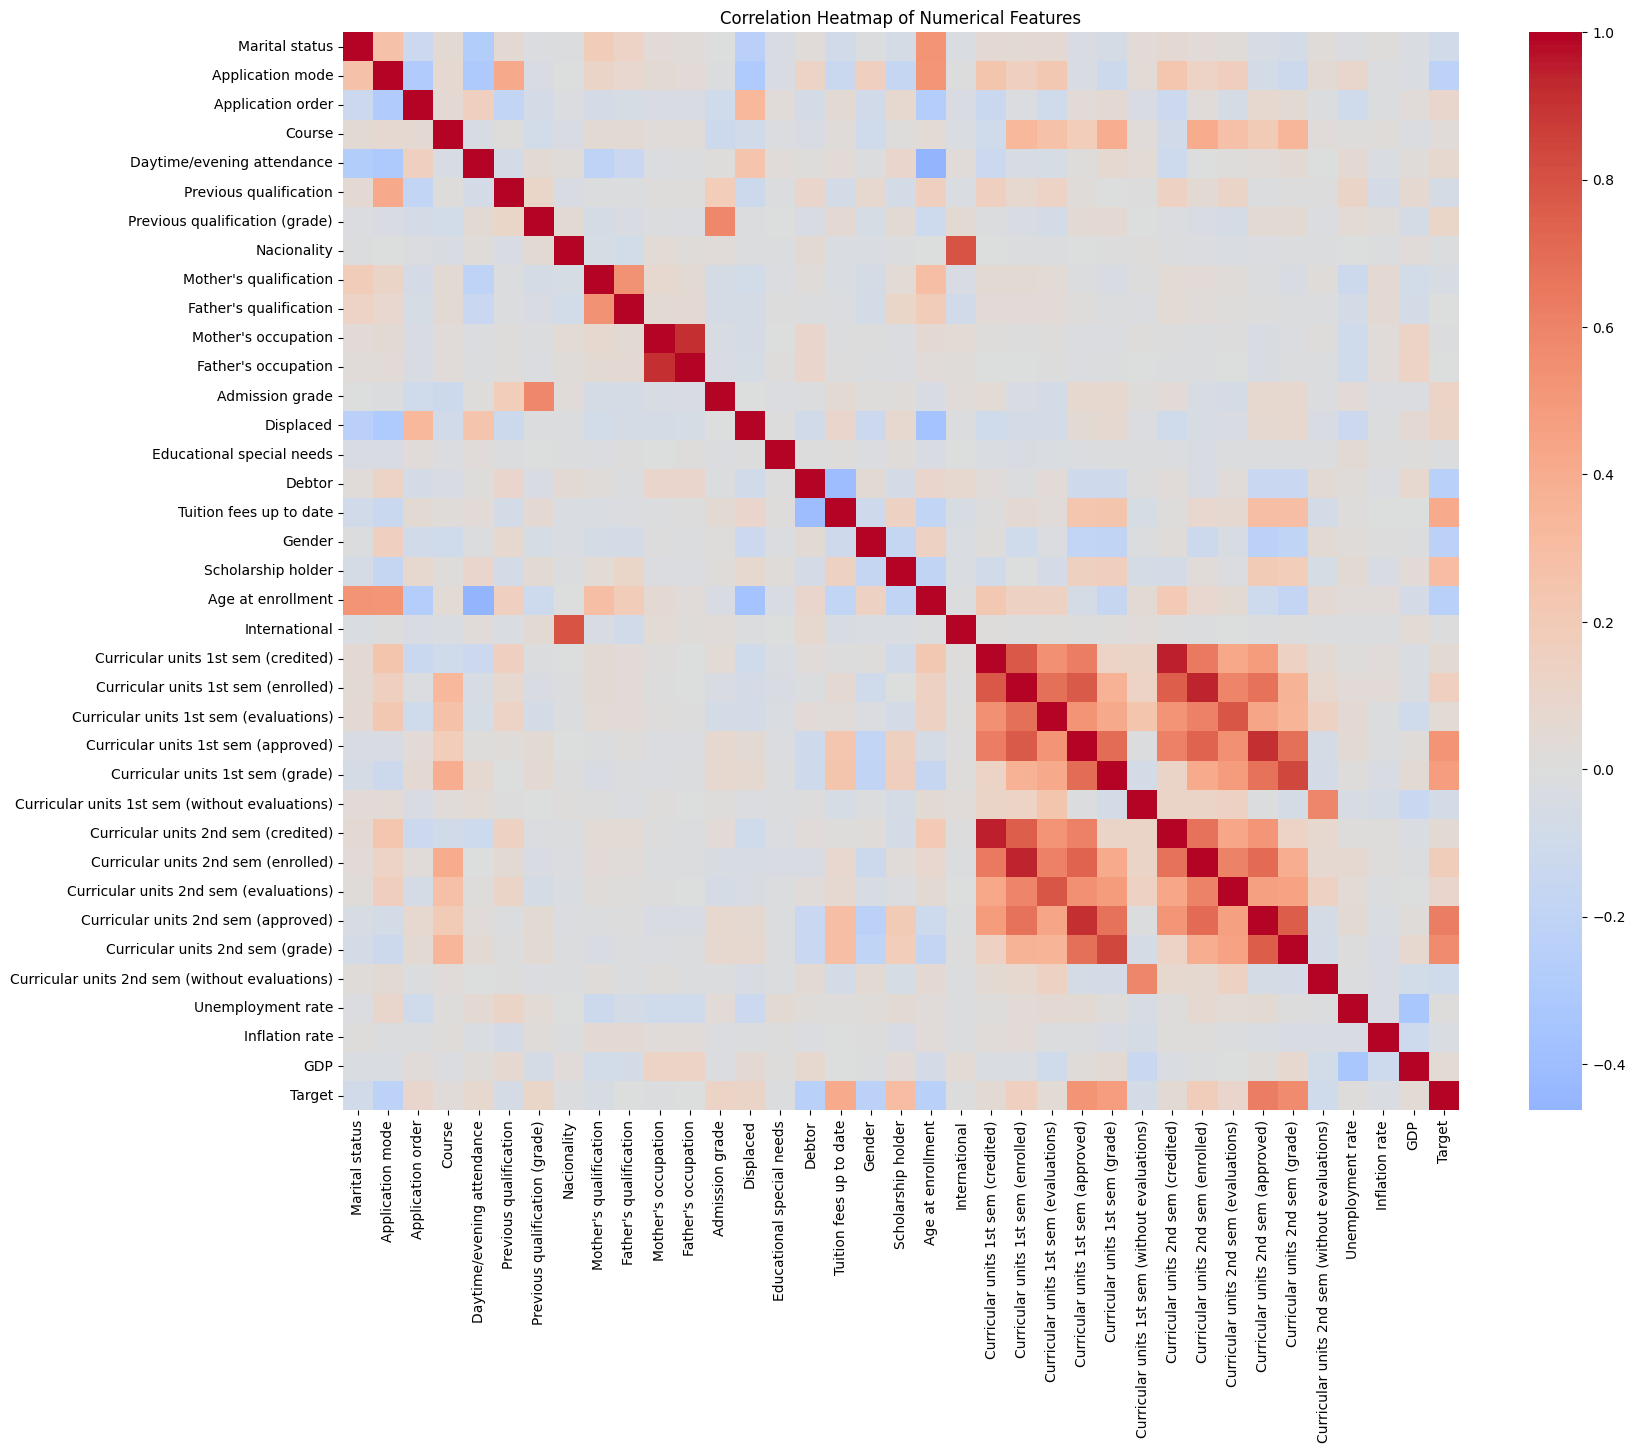

In [ ]:
plt.figure(figsize=(18,14))
# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

/tmp/ipython-input-318431682.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


--- Visualization Code Provided for RQ1 ---


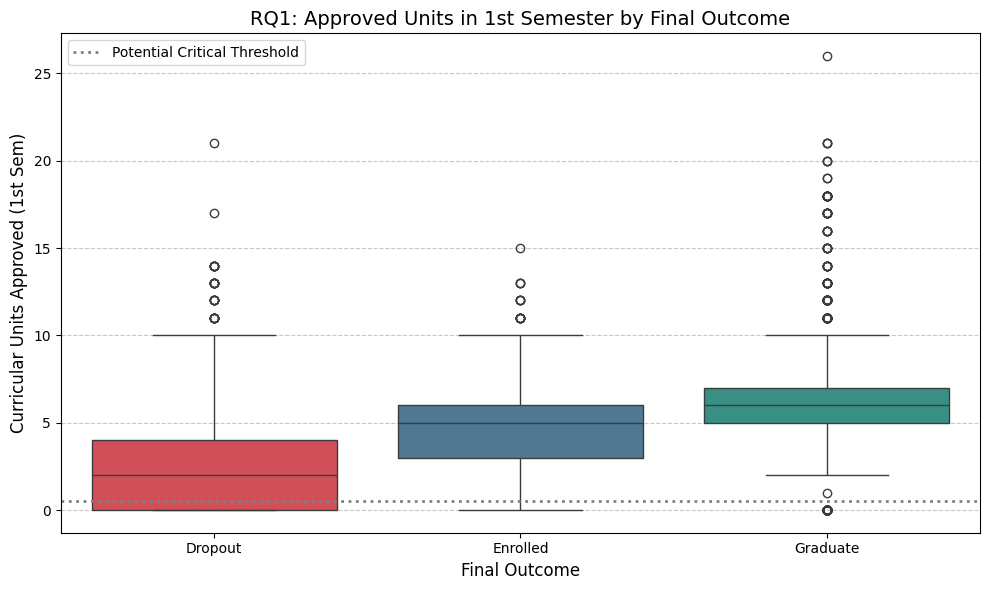

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Clean Column Names
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Feature Engineering: Calculate Semester 1 Success Rate
df['Sem 1 Success Rate'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'],
    0
)

# Set the order for the Target variable for consistent plotting
target_order = ['Dropout', 'Enrolled', 'Graduate']
df['Target'] = pd.Categorical(df['Target'], categories=target_order, ordered=True)

# Create an impactful box plot for visualization
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 1st sem (approved)',
    order=target_order,
    palette={'Dropout': '#E63946', 'Enrolled': '#457B9D', 'Graduate': '#2A9D8F'}
)
plt.title('RQ1: Approved Units in 1st Semester by Final Outcome', fontsize=14)
plt.xlabel('Final Outcome', fontsize=12)
plt.ylabel('Curricular Units Approved (1st Sem)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight the potential critical insight
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=2, label='Potential Critical Threshold')
plt.legend()

plt.tight_layout()
plt.savefig('approved_units_boxplot.png')
# Note: For presentation, you will need to display 'approved_units_boxplot.png'
print("--- Visualization Code Provided for RQ1 ---")

--- Visualization Code Provided for RQ2 ---


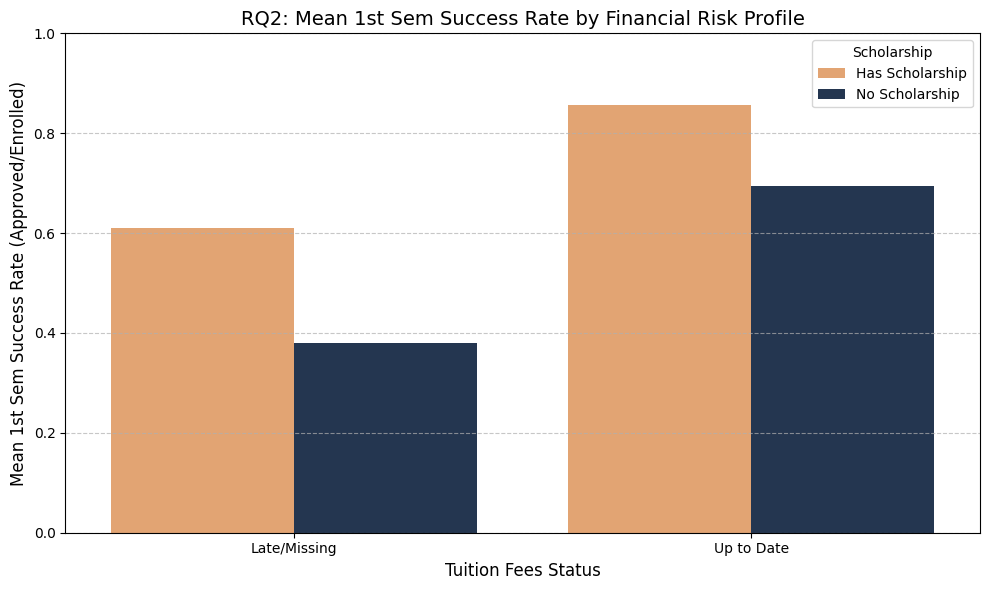

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Clean Column Names
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Feature Engineering: Calculate Semester 1 Success Rate
df['Sem 1 Success Rate'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'],
    0
)

# Map binary features to descriptive categories
df['Fees Status'] = df['Tuition fees up to date'].map({0: 'Late/Missing', 1: 'Up to Date'})
df['Scholarship Status'] = df['Scholarship holder'].map({0: 'No Scholarship', 1: 'Has Scholarship'})

# Group by the two financial features and calculate the mean success rate
grouped_financial = df.groupby(['Fees Status', 'Scholarship Status'])['Sem 1 Success Rate'].mean().reset_index()

# Create a bar plot to visualize the interaction
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped_financial,
    x='Fees Status',
    y='Sem 1 Success Rate',
    hue='Scholarship Status',
    palette={'No Scholarship': '#1D3557', 'Has Scholarship': '#F4A261'}
)
plt.title('RQ2: Mean 1st Sem Success Rate by Financial Risk Profile', fontsize=14)
plt.xlabel('Tuition Fees Status', fontsize=12)
plt.ylabel('Mean 1st Sem Success Rate (Approved/Enrolled)', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Scholarship')
plt.tight_layout()
plt.savefig('financial_risk_success_rate.png')

print("--- Visualization Code Provided for RQ2 ---")

/tmp/ipython-input-2525245609.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-2525245609.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


--- Visualization Code Provided for RQ3 ---


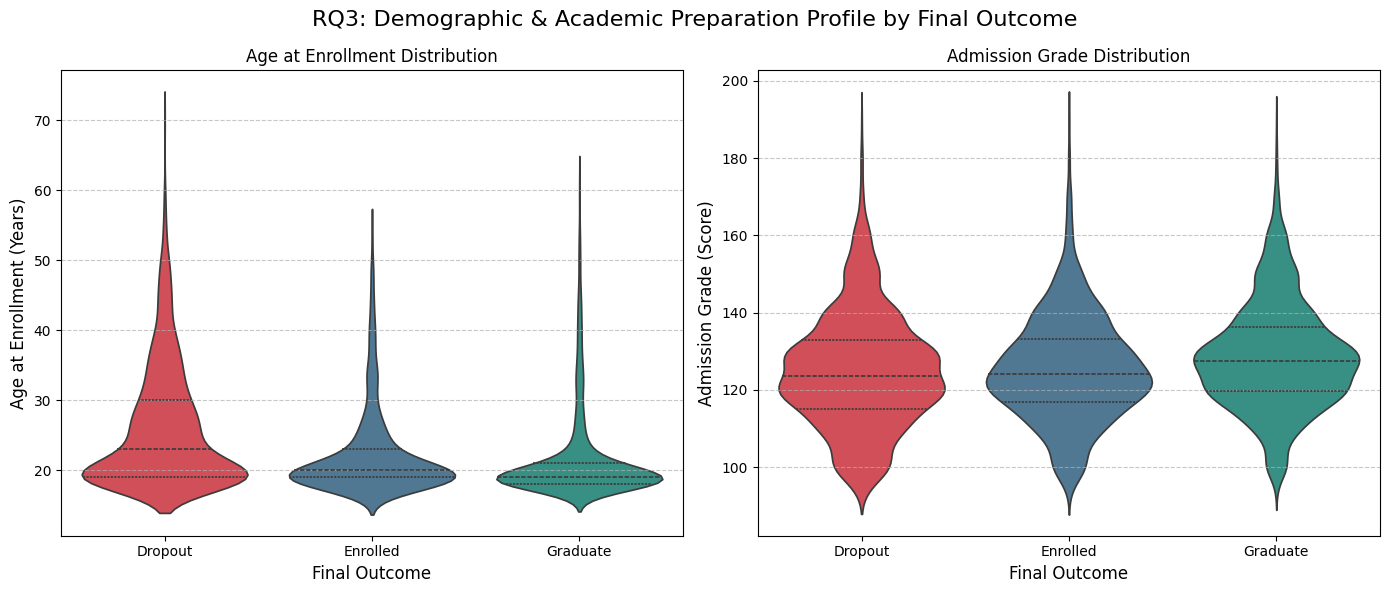

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Clean Column Names
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Define the order for the Target variable for consistent plotting
target_order = ['Dropout', 'Enrolled', 'Graduate']
df['Target'] = pd.Categorical(df['Target'], categories=target_order, ordered=True)

# Create a figure with two side-by-side violin plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle('RQ3: Demographic & Academic Preparation Profile by Final Outcome', fontsize=16)

# Plot 1: Age at Enrollment Distribution
sns.violinplot(
    ax=axes[0],
    data=df,
    x='Target',
    y='Age at enrollment',
    order=target_order,
    palette={'Dropout': '#E63946', 'Enrolled': '#457B9D', 'Graduate': '#2A9D8F'},
    inner='quartile'
)
axes[0].set_title('Age at Enrollment Distribution', fontsize=12)
axes[0].set_xlabel('Final Outcome', fontsize=12)
axes[0].set_ylabel('Age at Enrollment (Years)', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Admission Grade Distribution
sns.violinplot(
    ax=axes[1],
    data=df,
    x='Target',
    y='Admission grade',
    order=target_order,
    palette={'Dropout': '#E63946', 'Enrolled': '#457B9D', 'Graduate': '#2A9D8F'},
    inner='quartile'
)
axes[1].set_title('Admission Grade Distribution', fontsize=12)
axes[1].set_xlabel('Final Outcome', fontsize=12)
axes[1].set_ylabel('Admission Grade (Score)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('demographic_academic_profile.png')

print("--- Visualization Code Provided for RQ3 ---")

/tmp/ipython-input-3805125307.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_risk_courses['Course Name'] = high_risk_courses['Course'].map(course_mapping).fillna('Other Course')


--- Visualization Code Provided for RQ4 ---


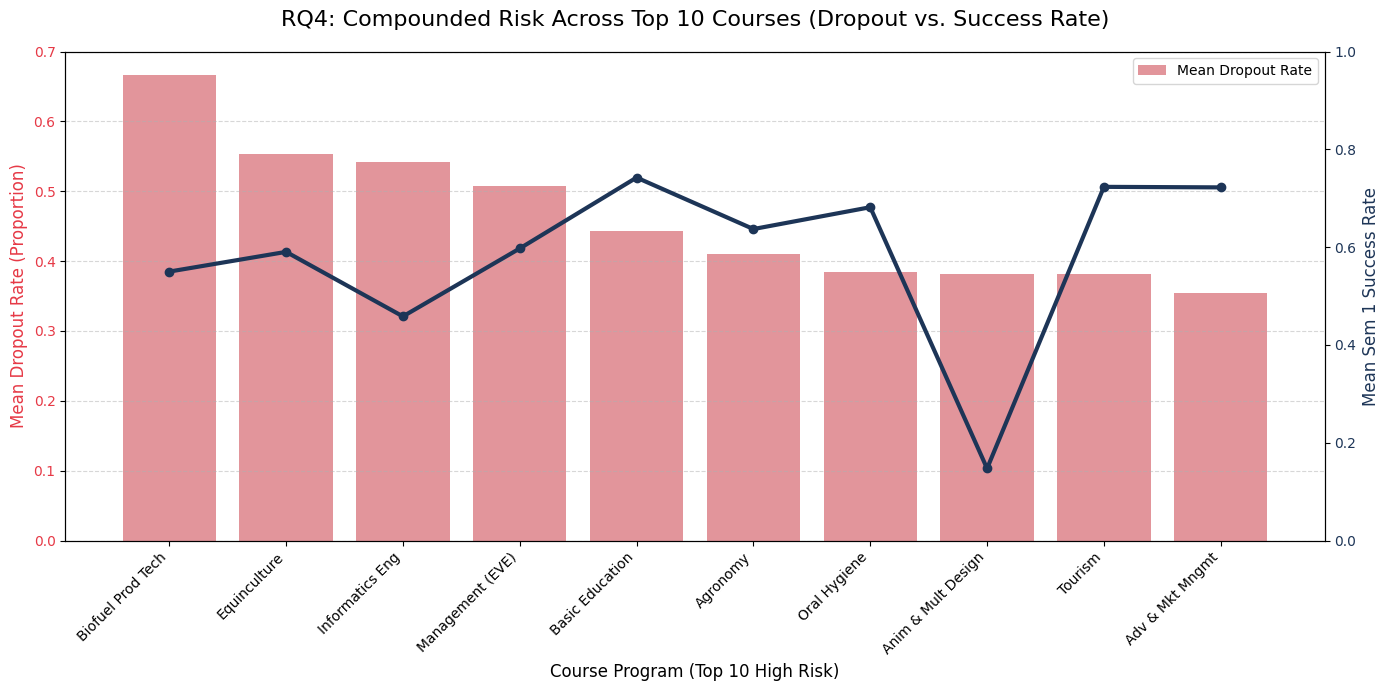

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Clean Column Names
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Feature Engineering: Calculate Semester 1 Success Rate and Dropout Indicator
df['Sem 1 Success Rate'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'],
    0
)
# Create a binary indicator for Dropout (1=Dropout, 0=Not Dropout)
df['Is Dropout'] = np.where(df['Target'] == 'Dropout', 1, 0)

# Calculate aggregated metrics per Course
course_risk_df = df.groupby('Course').agg(
    Mean_Success_Rate=('Sem 1 Success Rate', 'mean'),
    Mean_Dropout_Rate=('Is Dropout', 'mean'),
    Mean_Admission_Grade=('Admission grade', 'mean')
).reset_index()

# Sort by Mean_Dropout_Rate for impactful presentation
course_risk_df = course_risk_df.sort_values(by='Mean_Dropout_Rate', ascending=False)

# Focus on the Top 10 High-Risk Courses for the visualization
top_n = 10
high_risk_courses = course_risk_df.head(top_n)

# Mapping the Course codes to their descriptions (for better readability)
course_mapping = {
    171: 'Anim & Mult Design', 8014: 'Social Service (EVE)', 9003: 'Agronomy',
    9070: 'Comm Design', 9085: 'Vet Nursing', 9119: 'Informatics Eng',
    9130: 'Equinculture', 9147: 'Management', 9238: 'Social Service',
    9254: 'Tourism', 9500: 'Nursing', 9556: 'Oral Hygiene',
    9670: 'Adv & Mkt Mngmt', 9773: 'Journalism', 9853: 'Basic Education',
    9991: 'Management (EVE)', 33: 'Biofuel Prod Tech' # Add more codes as needed based on output
}
high_risk_courses['Course Name'] = high_risk_courses['Course'].map(course_mapping).fillna('Other Course')

# Plotting the Compounded Risk (Dual-Axis Chart)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot 1: Mean Dropout Rate (Bars - Left Y-axis)
color = '#E63946'
sns.barplot(
    x='Course Name',
    y='Mean_Dropout_Rate',
    data=high_risk_courses,
    ax=ax1,
    color=color,
    alpha=0.6,
    label='Mean Dropout Rate'
)
ax1.set_xlabel('Course Program (Top 10 High Risk)', fontsize=12)
ax1.set_ylabel('Mean Dropout Rate (Proportion)', color=color, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.get_xticklabels(), ha='right') # Correctly set horizontal alignment
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Mean Sem 1 Success Rate (Line Plot - Right Y-axis)
ax2 = ax1.twinx()
color = '#1D3557'
ax2.plot(
    high_risk_courses['Course Name'],
    high_risk_courses['Mean_Success_Rate'],
    color=color,
    marker='o',
    linewidth=3,
    label='Mean Sem 1 Success Rate'
)
ax2.set_ylabel('Mean Sem 1 Success Rate', color=color, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1.0) # Scale between 0 and 1.0

fig.suptitle(f'RQ4: Compounded Risk Across Top {top_n} Courses (Dropout vs. Success Rate)', fontsize=16)
fig.tight_layout()
plt.savefig('course_compounded_risk_eda.png')

print("--- Visualization Code Provided for RQ4 ---")

In [ ]:
# ==========================
# OPTIMIZED DECISION TREE PIPELINE
# ==========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ----------------------
# Load & prepare dataset
# ----------------------
df = pd.read_csv("data.csv")
df.columns = df.columns.str.strip().str.replace("\t","")

target_map = {"Dropout":0, "Enrolled":1, "Graduate":2}
df["Target"] = df["Target"].map(target_map)

X = df.drop("Target", axis=1)
y = df["Target"]

In [ ]:
# ----------------------
# Feature selection
# ----------------------
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

X = X[selected_features]

In [ ]:
# ----------------------
# Train-test split
# ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
# ----------------------------------------
# Class imbalance handling: SMOTE + Tomek
# ----------------------------------------
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

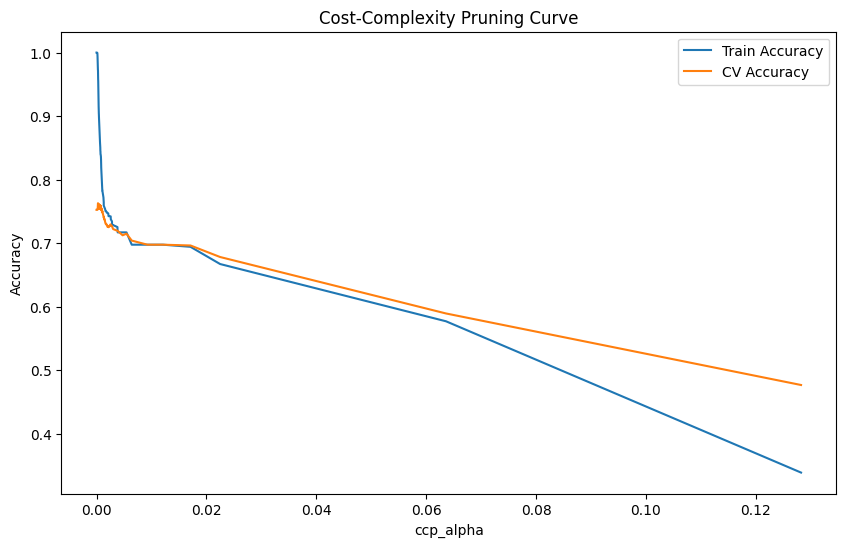

In [ ]:
# ----------------------------------------
# Cost-complexity pruning (ccp_alpha path)
# ----------------------------------------
dt_temp = DecisionTreeClassifier(random_state=42)
path = dt_temp.cost_complexity_pruning_path(X_train_res, y_train_res)
ccp_alphas = path.ccp_alphas

train_scores = []
val_scores = []

for c in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=c)
    clf.fit(X_train_res, y_train_res)
    train_scores.append(clf.score(X_train_res, y_train_res))
    val_scores.append(np.mean(cross_val_score(clf, X_train_res, y_train_res, cv=5)))

# Plot CCP curve
plt.figure(figsize=(10,6))
plt.plot(ccp_alphas, train_scores, label="Train Accuracy")
plt.plot(ccp_alphas, val_scores, label="CV Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Cost-Complexity Pruning Curve")
plt.legend()
plt.show()

In [ ]:
# ------------------------------------------------------
# Hyperparameter tuning grid (FULL OPTIMIZED TREE GRID)
# ------------------------------------------------------
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced", {0:1,1:4,2:1}],
    "ccp_alpha": np.linspace(0, max(ccp_alphas), 10)
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

best_tree = grid.best_estimator_

print("====== Best Parameters Found ======")
print(grid.best_params_)
print("\n")

====== Best Parameters Found ======
{'ccp_alpha': np.float64(0.0), 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}




====== OPTIMIZED DECISION TREE RESULTS ======
              precision    recall  f1-score   support

           0       0.70      0.63      0.66       355
           1       0.32      0.43      0.37       199
           2       0.80      0.76      0.78       552

    accuracy                           0.66      1106
   macro avg       0.61      0.61      0.60      1106
weighted avg       0.68      0.66      0.67      1106



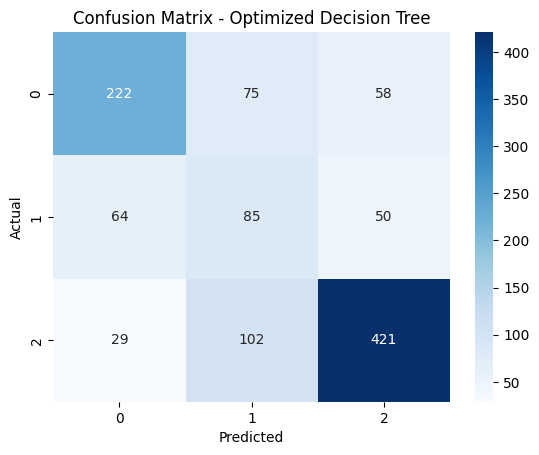

In [ ]:
# ----------------------
# Evaluate optimized model
# ----------------------
y_pred = best_tree.predict(X_test)

print("====== OPTIMIZED DECISION TREE RESULTS ======")
print(classification_report(y_test, y_pred))

# ----------------------
# Confusion matrix
# ----------------------
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Optimized Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

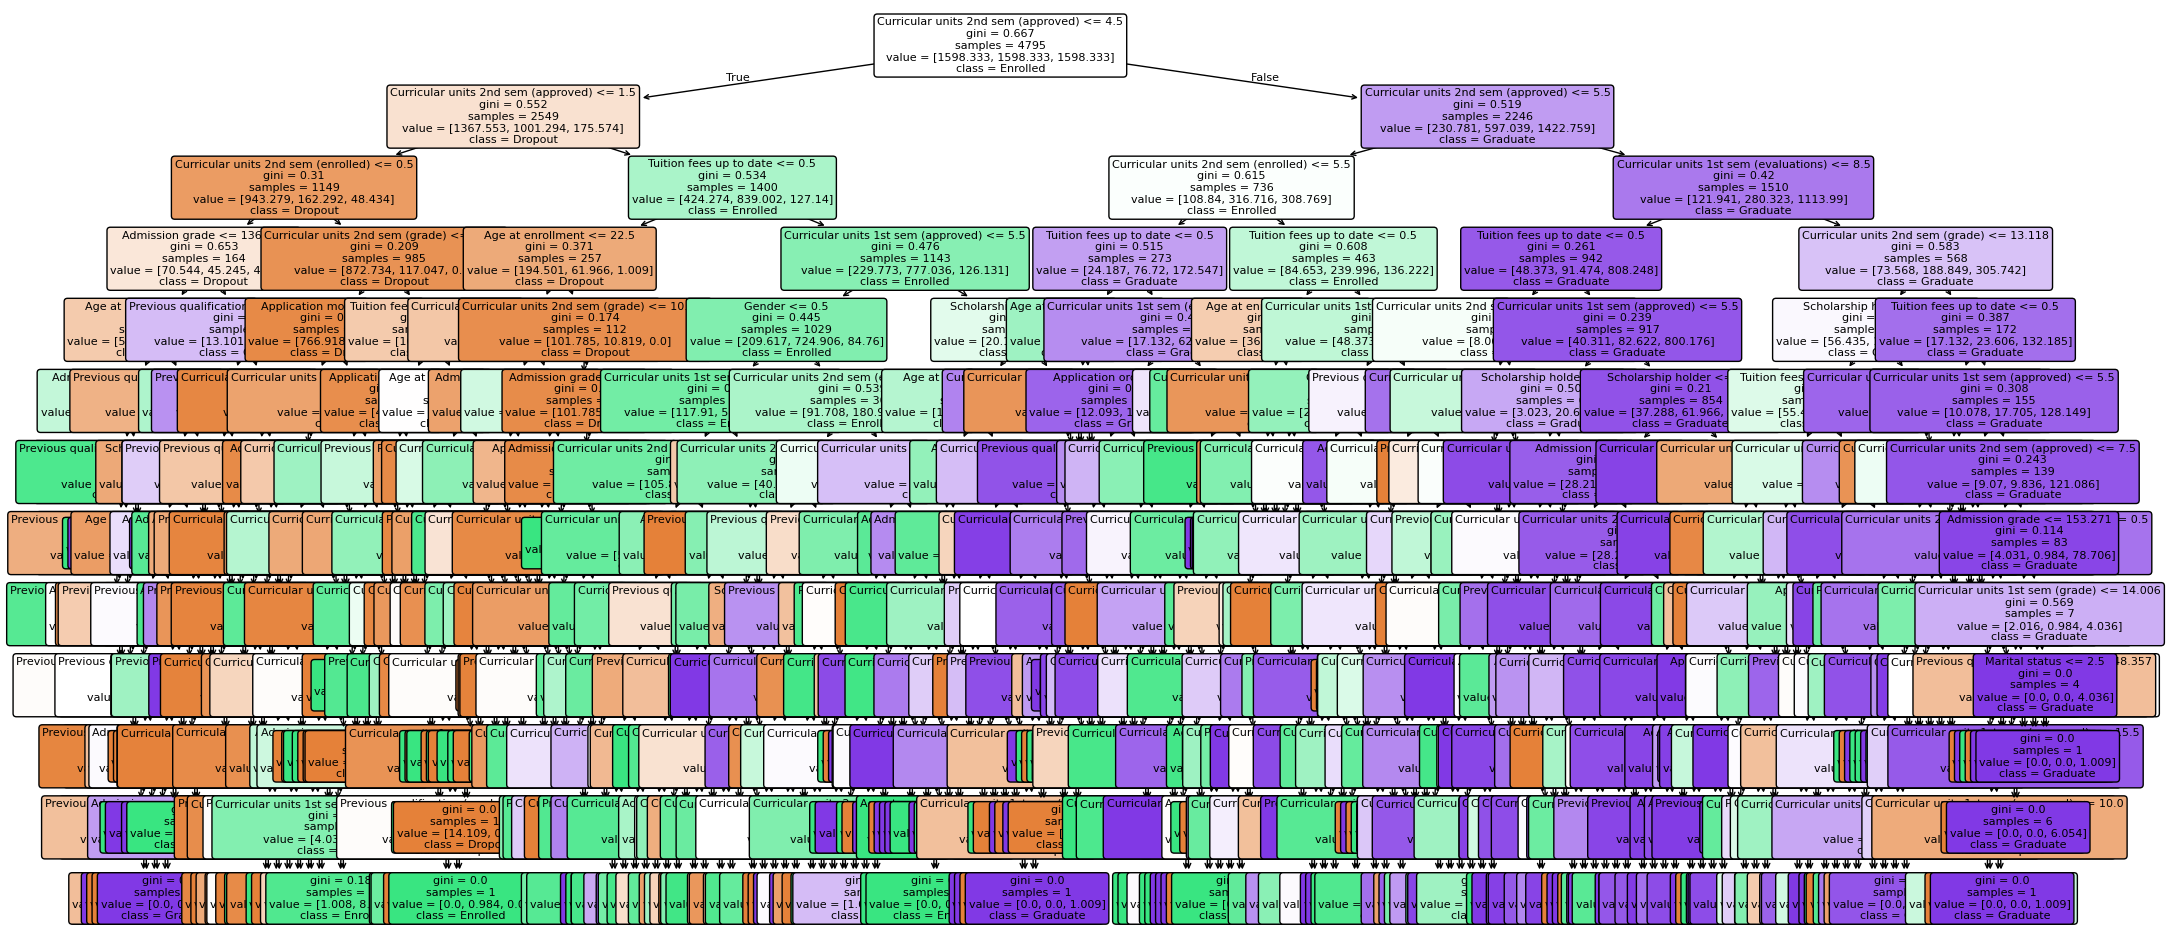

In [ ]:
# ----------------------------------
# Visualize final optimized decision tree
# ----------------------------------
plt.figure(figsize=(25,12))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=["Dropout", "Enrolled", "Graduate"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [ ]:
#----------------------------------
# Final performance score
# ----------------------------------
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1 Score of Optimized Tree: {macro_f1:.4f}")

Macro F1 Score of Optimized Tree: 0.6035


In [ ]:
# ===========================================================
# MASTER OPTIMIZED DECISION TREE PIPELINE (CLASS 1 BOOSTED)
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Added joblib for saving/loading

from sklearn.model_selection import train_test_split, GridSearchCV # GridSearchCV for tuning
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve, accuracy_score # Added accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.calibration import CalibratedClassifierCV # Moved import here

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler # Added for potential undersampling

# Added warnings filter for cleaner output
import warnings
warnings.filterwarnings("ignore")

# --------------------------------------
# 1. Load and prepare dataset
# --------------------------------------
df = pd.read_csv("data.csv")
df.columns = df.columns.str.strip().str.replace("\t","")

target_map = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
df["Target"] = df["Target"].map(target_map)

X = df.drop("Target", axis=1)
y = df["Target"]

KeyError: 'Target'

In [ ]:
# --------------------------------------
# 5. Cost Complexity Pruning Path
# --------------------------------------
dt_temp = DecisionTreeClassifier(random_state=42)
path = dt_temp.cost_complexity_pruning_path(X_train_res, y_train_res)
ccp_alphas = path.ccp_alphas



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 6, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt"],
    "class_weight": [
        None,
        "balanced",
        {0:1, 1:6, 2:1},
        {0:1, 1:10, 2:1}
    ],
    "ccp_alpha": np.linspace(0, max(ccp_alphas), 15)
}

rand = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,                  # try only 50 combos instead of thousands
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    random_state=42
)

rand.fit(X_train_res, y_train_res)
best_tree = rand.best_estimator_
print(rand.best_params_)


{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 12, 'criterion': 'gini', 'class_weight': {0: 1, 1: 6, 2: 1}, 'ccp_alpha': np.float64(0.0)}


In [ ]:
# --------------------------------------
# 7. Calibrate model (important for threshold tuning)
# --------------------------------------
calibrated_model = CalibratedClassifierCV(best_tree, method="sigmoid", cv=5)
calibrated_model.fit(X_train_res, y_train_res)

# --------------------------------------
# 8. Evaluate normally
# --------------------------------------
y_pred_normal = calibrated_model.predict(X_test)
print("=== BEFORE THRESHOLD TUNING ===")
print(classification_report(y_test, y_pred_normal))

# --------------------------------------
# 9. Threshold Tuning for CLASS 1
# --------------------------------------
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test==1, y_proba)

# Choose threshold that maximizes F1 for class 1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"\nBest Threshold for Class 1 = {best_thresh:.3f}\n")

y_pred_tuned = []
for i, p in enumerate(y_proba):
    if p > best_thresh:
        y_pred_tuned.append(1)
    else:
        y_pred_tuned.append(y_pred_normal[i])

print("=== AFTER THRESHOLD TUNING ===")
print(classification_report(y_test, y_pred_tuned))

# --------------------------------------
# 10. Confusion Matrix
# --------------------------------------
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Threshold Tuned Decision Tree")
plt.show()

# --------------------------------------
# 11. Final Tree Visualization
# --------------------------------------
plt.figure(figsize=(25, 12))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=["Dropout","Enrolled","Graduate"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

# --------------------------------------
# 12. Final Macro F1 Score
# --------------------------------------
final_macro_f1 = f1_score(y_test, y_pred_tuned, average="macro")
print("Final Macro F1 after all optimizations:", final_macro_f1)


NameError: name 'best_tree' is not defined

In [ ]:
# Cell 1: Imports & configuration
# All necessary imports for this pipeline have been moved to cell B-gfpCzKQiKB to avoid NameErrors. This cell can be removed or kept as is if other functionalities were intended here.

In [ ]:
# Cell 2: Load data and quick checks
df = pd.read_csv(DATA_PATH)
# cleanup column names (strip spaces & tabs)
df.columns = df.columns.str.strip().str.replace("\t", " ").str.replace("\n"," ").str.replace("  "," ")
print("Shape:", df.shape)
print(df.dtypes.value_counts())
print("\nTarget distribution:\n", df['Target'].value_counts())

# show first rows
df.head()


Shape: (4424, 37)
int64      29
float64     7
object      1
Name: count, dtype: int64

Target distribution:
 Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


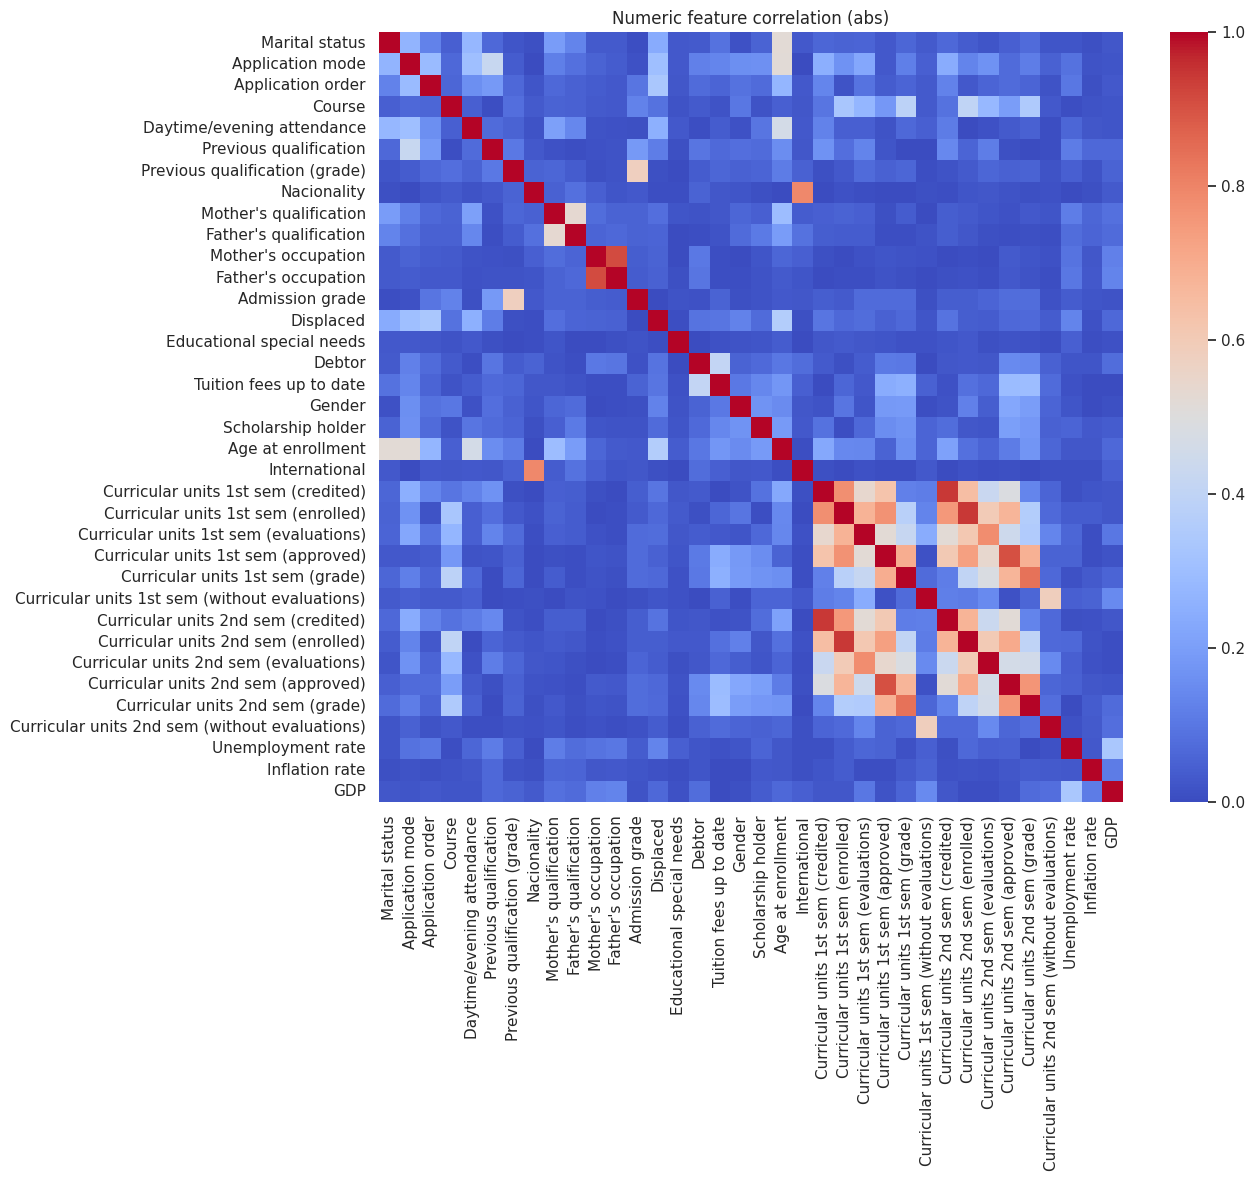

Dropping 4 features with |corr| > 0.85:
 ["Father's occupation", 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']
New shape after drop: (4424, 33)


In [ ]:
# Cell 3: Drop highly correlated numeric features (abs corr > 0.85)
num_df = df.select_dtypes(include=[np.number]).copy()

# Exclude target if numeric (Target is object in your dataset, but safe-guard)
if 'Target' in num_df.columns:
    num_df = num_df.drop(columns=['Target'])

corr = num_df.corr().abs()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Numeric feature correlation (abs)")
plt.show()

# Find pairs above threshold (upper triangle)
threshold = 0.85
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print(f"Dropping {len(to_drop)} features with |corr| > {threshold}:\n", to_drop)

# Drop from df
df = df.drop(columns=to_drop)
print("New shape after drop:", df.shape)


In [ ]:
# Cell 4: Prepare X and y, encode target to integers if not already
# Ensure Target column exactly spelled; adjust if necessary
target_col = "Target"
if df[target_col].dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])
    class_names = le.classes_.tolist()
else:
    # assume already numeric 0/1/2 mapping
    class_names = sorted(df[target_col].unique().tolist())

X = df.drop(columns=[target_col])
y = df[target_col].values

print("Classes:", class_names)
print("X shape:", X.shape)


Classes: ['Dropout', 'Enrolled', 'Graduate']
X shape: (4424, 32)


In [ ]:
# Cell 5: Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RND
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class counts:\n", pd.Series(y_train).value_counts())


Train: (3539, 32) Test: (885, 32)
Train class counts:
 2    1767
0    1137
1     635
Name: count, dtype: int64


In [ ]:
# Cell 6: Apply SMOTE-ENN to training set (clean + oversample minority)
print("Before SMOTEENN:", pd.Series(y_train).value_counts())

smt = SMOTEENN(random_state=RND)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("After SMOTEENN:", pd.Series(y_train_res).value_counts())


Before SMOTEENN: 2    1767
0    1137
1     635
Name: count, dtype: int64
After SMOTEENN: 1    1094
0     793
2     564
Name: count, dtype: int64


In [ ]:
# Cell 7: Safe targeted oversampling for class 1 (increase up to factor)
from collections import Counter
counts = Counter(y_train_res)
print("Counts after SMOTEENN:", counts)

# configure factor (1.0 = no change, 1.3 = +30% of current)
target_factor = 1.3

current_c1 = counts.get(1, 0)
desired_c1 = int(current_c1 * target_factor)

if desired_c1 > current_c1:
    ros = RandomOverSampler(sampling_strategy={1: desired_c1}, random_state=RND)
    X_train_res, y_train_res = ros.fit_resample(X_train_res, y_train_res)
    print("After targeted ROS:", Counter(y_train_res))
else:
    print("Skipping targeted ROS: desired <= current")


Counts after SMOTEENN: Counter({np.int64(1): 1094, np.int64(0): 793, np.int64(2): 564})
After targeted ROS: Counter({np.int64(1): 1422, np.int64(0): 793, np.int64(2): 564})


In [ ]:
# Cell 8: Optional safe undersampling of the largest class to reduce dominance
from collections import Counter
counts = Counter(y_train_res)
major_class = max(counts, key=counts.get)
print("Current counts:", counts)

# only undersample if majority is much larger than others
if counts[major_class] > 1.6 * counts.get(1,1):   # threshold can be tuned
    target_count = int(1.2 * counts.get(1,1))  # keep majority ~20% larger than class1
    rus = RandomUnderSampler(sampling_strategy={major_class: target_count}, random_state=RND)
    X_train_res, y_train_res = rus.fit_resample(X_train_res, y_train_res)
    print("After undersampling:", Counter(y_train_res))
else:
    print("Skipping undersampling: majority not excessively large")


Current counts: Counter({np.int64(1): 1422, np.int64(0): 793, np.int64(2): 564})
Skipping undersampling: majority not excessively large


In [ ]:
# Cell 9: Build a scaler (we will use scaler inside pipeline and for final training)
scaler = StandardScaler()
# Fit scaler on resampled training data (we'll apply in pipelines too)
scaler.fit(X_train_res)
X_train_res_scaled = scaler.transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Cell 10: Compute cost-complexity pruning path to get ccp_alphas range
temp_tree = DecisionTreeClassifier(random_state=RND)
temp_tree.fit(X_train_res_scaled, y_train_res)
path = temp_tree.cost_complexity_pruning_path(X_train_res_scaled, y_train_res)
ccp_alphas = path.ccp_alphas
print("ccp_alphas (example):", np.round(ccp_alphas[:8], 6))


ccp_alphas (example): [0.       0.000239 0.000332 0.000342 0.000342 0.000346 0.000349 0.00035 ]


In [ ]:
# Cell 11: Randomized hyperparameter search (fast) optimizing f1_macro
from scipy.stats import randint
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", {0:1,1:3,2:1}, {0:1,1:5,2:1}, {0:1,1:8,2:1}],
    "ccp_alpha": np.linspace(0.0, max(ccp_alphas), 12)
}

dt = DecisionTreeClassifier(random_state=RND)
rand = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=60,            # adjust for speed: 40-100 recommended
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    random_state=RND,
    verbose=1
)

# Fit on scaled resampled training set
rand.fit(X_train_res_scaled, y_train_res)
best_tree = rand.best_estimator_
print("Best params:", rand.best_params_)
print("Best CV f1_macro:", rand.best_score_)


Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best params: {'ccp_alpha': np.float64(0.0), 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 7}
Best CV f1_macro: 0.7985074885342002


In [ ]:
# Cell 12: Calibrate probabilities using sigmoid (Platt)
calibrator = CalibratedClassifierCV(best_tree, method="sigmoid", cv=3)
calibrator.fit(X_train_res_scaled, y_train_res)

# quick check: accuracy & f1 on validation (test)
y_pred_base = calibrator.predict(X_test_scaled)
print("Post-calibration (default threshold) metrics:")
print(classification_report(y_test, y_pred_base, target_names=[str(x) for x in class_names]))


Post-calibration (default threshold) metrics:
              precision    recall  f1-score   support

     Dropout       0.79      0.55      0.64       284
    Enrolled       0.30      0.69      0.42       159
    Graduate       0.87      0.63      0.73       442

    accuracy                           0.62       885
   macro avg       0.65      0.62      0.60       885
weighted avg       0.74      0.62      0.65       885



In [ ]:
# Cell 13: Tune threshold for class 1 to balance precision/recall
probs = calibrator.predict_proba(X_test_scaled)  # shape (n_samples, n_classes)
# We'll tune a single threshold for class 1; if prob1 > t => predict 1, else predict argmax of others
prob1 = probs[:, 1]

prec, rec, thr = precision_recall_curve((y_test == 1).astype(int), prob1)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thresh = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"Best threshold for class 1 (by F1): {best_thresh:.3f}")

# Construct tuned predictions:
y_pred_tuned = []
for i in range(len(prob1)):
    if prob1[i] >= best_thresh:
        y_pred_tuned.append(1)
    else:
        # choose class with highest probability among other classes (0 and 2)
        other_probs = probs[i].copy()
        other_probs[1] = -1  # exclude class1
        y_pred_tuned.append(int(np.argmax(other_probs)))

# Evaluate
print("=== Metrics after threshold tuning for class 1 ===")
print(classification_report(y_test, y_pred_tuned, target_names=[str(x) for x in class_names]))
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))


Best threshold for class 1 (by F1): 0.543
=== Metrics after threshold tuning for class 1 ===
              precision    recall  f1-score   support

     Dropout       0.76      0.57      0.65       284
    Enrolled       0.33      0.67      0.45       159
    Graduate       0.86      0.68      0.76       442

    accuracy                           0.64       885
   macro avg       0.65      0.64      0.62       885
weighted avg       0.73      0.64      0.67       885

Accuracy: 0.6440677966101694


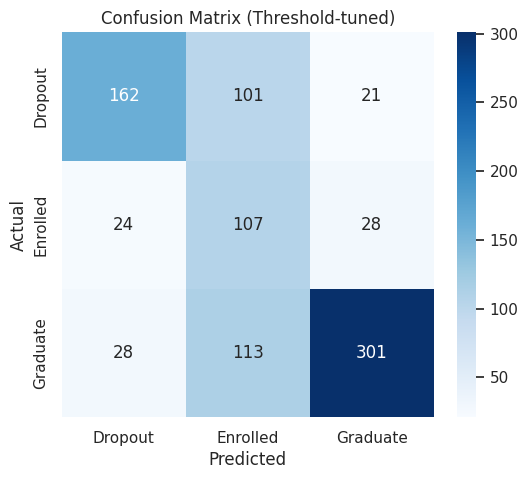

Macro F1: 0.6188455843576325
Per-class support: {2: 442, 0: 284, 1: 159}


In [ ]:
# Cell 14: Final confusion matrix and key metrics
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold-tuned)")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred_tuned, average="macro"))
print("Per-class support:", pd.Series(y_test).value_counts().to_dict())


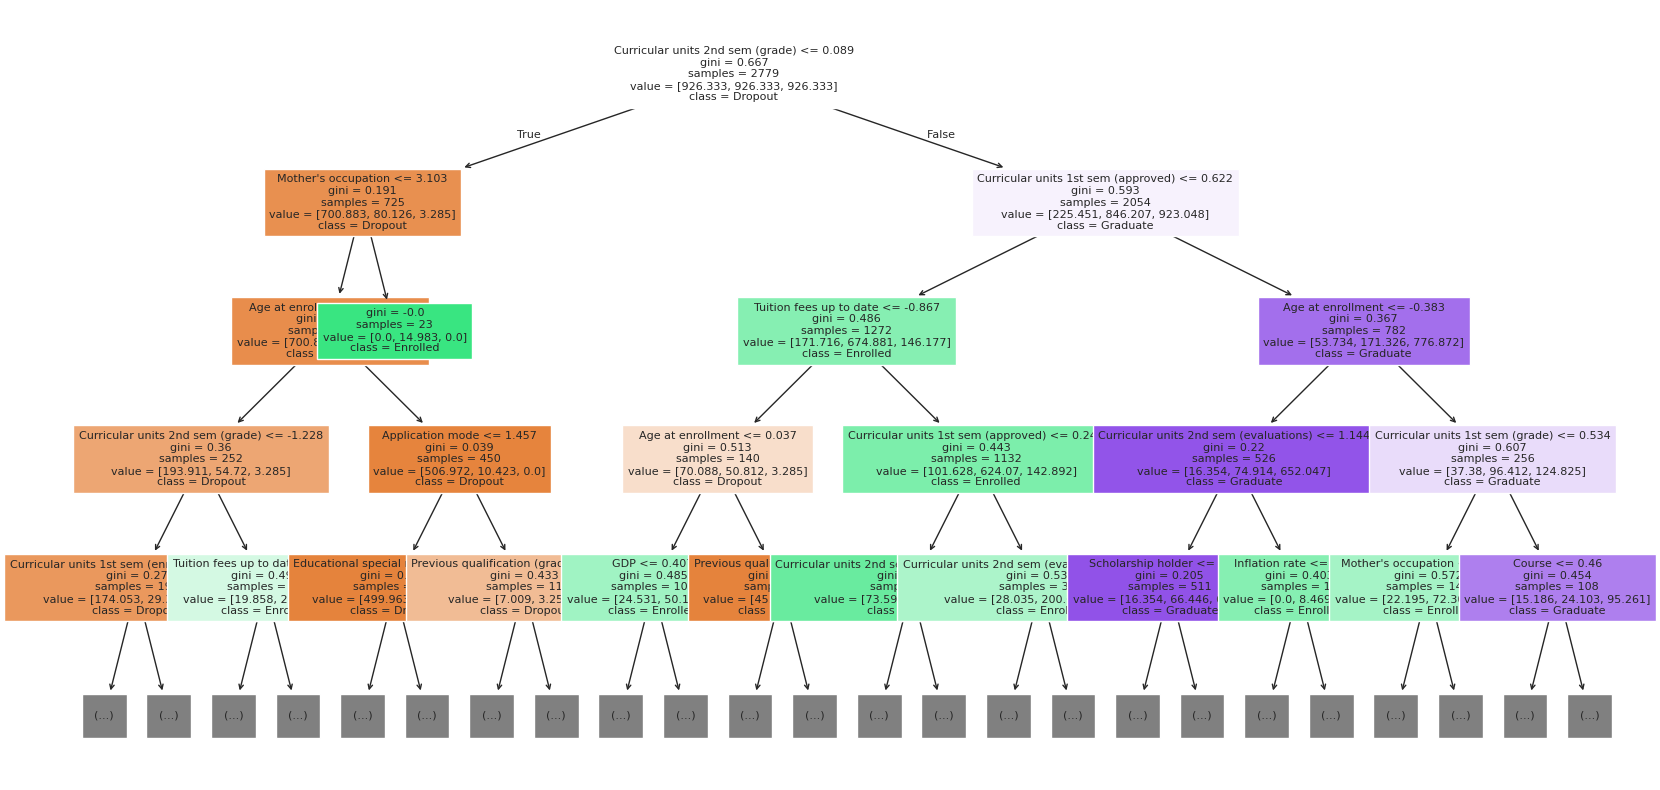

|--- Curricular units 2nd sem (grade) <= 0.09
|   |--- Mother's occupation <= 3.10
|   |   |--- Age at enrollment <= -0.38
|   |   |   |--- Curricular units 2nd sem (grade) <= -1.23
|   |   |   |   |--- Curricular units 1st sem (enrolled) <= -2.99
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- Curricular units 1st sem (enrolled) >  -2.99
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Curricular units 2nd sem (grade) >  -1.23
|   |   |   |   |--- Tuition fees up to date <= -0.87
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Tuition fees up to date >  -0.87
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |--- Age at enrollment >  -0.38
|   |   |   |--- Application mode <= 1.46
|   |   |   |   |--- Educational special needs <= 6.53
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- Educational special needs >  6.53
|   |   |   |   |   |--- class: 0
|   |   |   |--- Application mode >  1.46
|   |

In [ ]:
# Cell 15: Visualize the fitted (best) decision tree (pruned via ccp_alpha/hyperparams)
# We plot the underlying (un-calibrated) best_tree fitted earlier; it's trained on scaled resampled data.
plt.figure(figsize=(20,10))
plot_tree(best_tree, feature_names=X.columns, class_names=[str(x) for x in class_names], filled=True, max_depth=4, fontsize=8)
plt.show()

# export text rules (first levels)
try:
    print(export_text(best_tree, feature_names=list(X.columns), max_depth=4))
except Exception:
    print("Text export failed for feature names.")


In [ ]:
# Cell 16: Save final artifacts: scaler, best_tree, calibrator, selected features, threshold and dropped features
artifacts = {
    "scaler": scaler,
    "best_tree": best_tree,
    "calibrator": calibrator,
    "selected_features": list(X.columns),
    "class_names": class_names,
    "threshold_class1": float(best_thresh),
    "dropped_features": to_drop
}
joblib.dump(artifacts, OUT_PATH)
print("Saved artifacts to:", OUT_PATH)


Saved artifacts to: /content/final_decision_tree_artifacts.joblib


>>> PHASE 1: PRE-MODEL PROCESSING...
   - Dropped 4 highly correlated features.
   - Generated 'methodology_class_balance.png'

>>> PHASE 2: MODEL TRAINING & OPTIMIZATION...
   - Base Model F1: 0.5776
   - Running RandomizedSearchCV...
   - Randomized Search F1: 0.6218
   - Running GridSearchCV (Coarse Grid)...
   - Grid Search F1: 0.5702

>>> PHASE 3: POST-MODEL REFINEMENT...
   - Generated 'model_evolution_metrics.png'
   - Generated 'model_comparison_table.png'

   SLIDE CONTENT GENERATOR REPORT

--- PRE-MODEL METRICS (For Slide: Data Processing) ---
Original Class 1 (Dropout) Count: 635
Resampled Class 1 Count: 1422
IMPROVEMENT: Increased minority representation by 124%

--- DURING-MODEL METRICS (For Slide: Modeling Strategy) ---
Base Model F1: 0.578
Randomized Search F1: 0.622 (Time efficient exploration)
Grid Search F1: 0.570 (Exhaustive search on key params)
Best Algo Params: {'ccp_alpha': np.float64(0.0), 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 6, 'max_fea

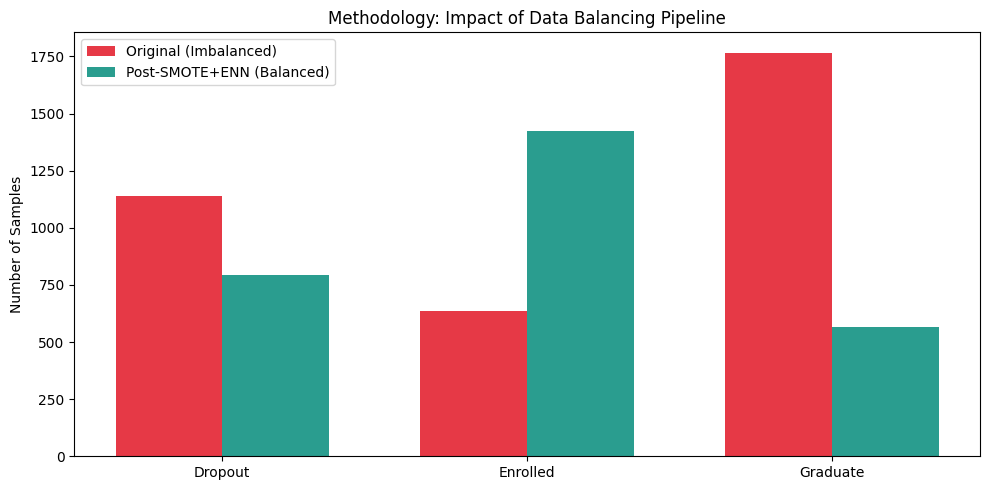

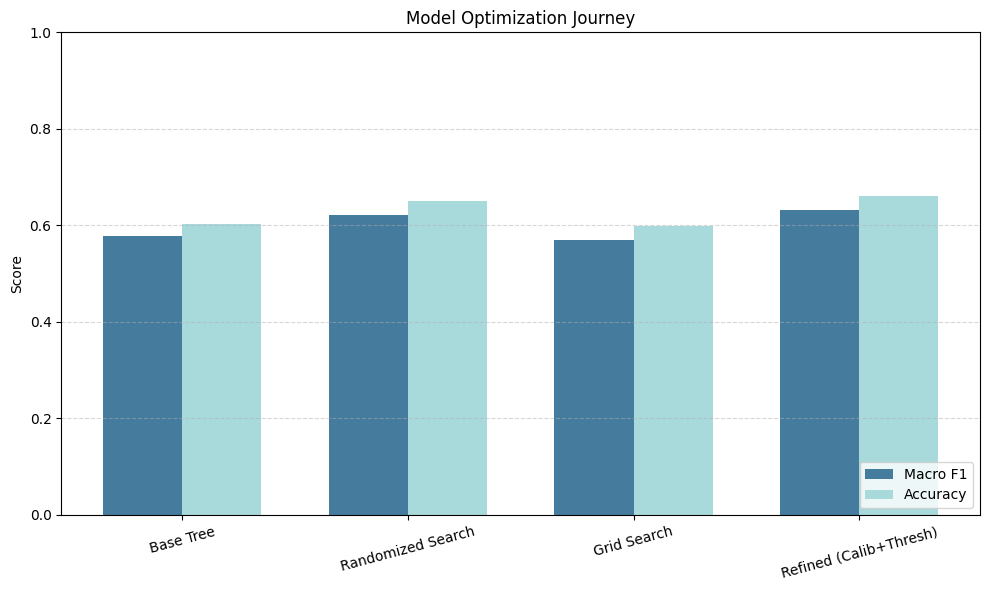

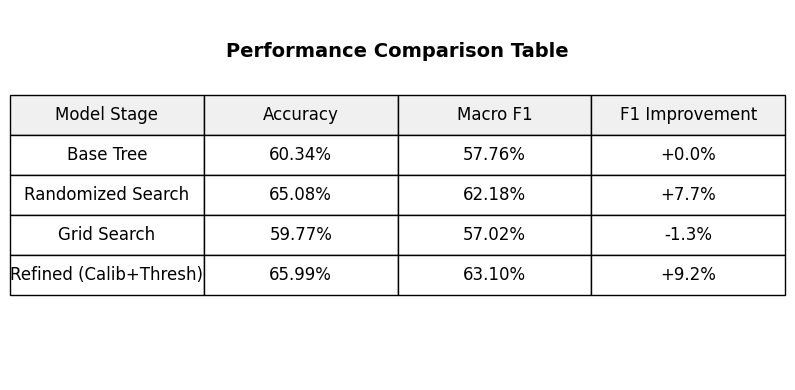

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, precision_recall_curve
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import randint

# --- CONFIGURATION ---
RND = 42
DATA_PATH = 'data.csv'

# --- 1. DATA LOADING & PREPROCESSING (PRE-MODEL) ---
print(">>> PHASE 1: PRE-MODEL PROCESSING...")
try:
    df = pd.read_csv(DATA_PATH, sep=';') # Try semicolon first
    if df.shape[1] < 5: # If read incorrectly
         df = pd.read_csv(DATA_PATH, sep=',')
except:
    df = pd.read_csv(DATA_PATH)

# Clean columns
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Drop Correlations (As per your analysis)
# Re-identifying the drops to ensure consistency
num_df = df.select_dtypes(include=[np.number])
if 'Target' in num_df.columns: num_df = num_df.drop(columns=['Target'])
corr = num_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
df = df.drop(columns=to_drop)
print(f"   - Dropped {len(to_drop)} highly correlated features.")

# Encode Target
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])
class_names = le.classes_
X = df.drop(columns=['Target'])
y = df['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RND)

# Capture Original Counts
original_counts = Counter(y_train)

# --- 2. ADVANCED RESAMPLING (PRE-MODEL) ---
# A. SMOTE-ENN
smt = SMOTEENN(random_state=RND)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

# B. Targeted Over-sampling (Class 1)
counts = Counter(y_train_res)
target_factor = 1.3
desired_c1 = int(counts[1] * target_factor)
ros = RandomOverSampler(sampling_strategy={1: desired_c1}, random_state=RND)
X_train_res, y_train_res = ros.fit_resample(X_train_res, y_train_res)

# C. Targeted Under-sampling (Majority)
counts = Counter(y_train_res)
major_class = max(counts, key=counts.get)
if counts[major_class] > 1.6 * counts.get(1, 1):
    target_count = int(1.2 * counts.get(1, 1))
    rus = RandomUnderSampler(sampling_strategy={major_class: target_count}, random_state=RND)
    X_train_res, y_train_res = rus.fit_resample(X_train_res, y_train_res)

# Capture Final Counts
final_counts = Counter(y_train_res)

# --- PLOT 1: Class Balance Evolution ---
plt.figure(figsize=(10, 5))
labels = [str(c) for c in class_names]
orig_vals = [original_counts[i] for i in range(3)]
final_vals = [final_counts[i] for i in range(3)]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, orig_vals, width, label='Original (Imbalanced)', color='#E63946')
plt.bar(x + width/2, final_vals, width, label='Post-SMOTE+ENN (Balanced)', color='#2A9D8F')
plt.ylabel('Number of Samples')
plt.title('Methodology: Impact of Data Balancing Pipeline')
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.savefig('methodology_class_balance.png')
print("   - Generated 'methodology_class_balance.png'")

# --- 3. MODEL TRAINING & OPTIMIZATION (DURING-MODEL) ---
print("\n>>> PHASE 2: MODEL TRAINING & OPTIMIZATION...")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Calculate ccp_alphas for search space
base_dt_pruning = DecisionTreeClassifier(random_state=RND)
path = base_dt_pruning.cost_complexity_pruning_path(X_train_scaled, y_train_res)
ccp_alphas = path.ccp_alphas

# A. Base Baseline (Before Tuning)
base_dt = DecisionTreeClassifier(random_state=RND)
base_dt.fit(X_train_scaled, y_train_res)
y_pred_base = base_dt.predict(X_test_scaled)
base_f1 = f1_score(y_test, y_pred_base, average='macro')
base_acc = accuracy_score(y_test, y_pred_base)
print(f"   - Base Model F1: {base_f1:.4f}")

# B. Randomized Search (Fast Tuning)
print("   - Running RandomizedSearchCV...")
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", {0:1,1:3,2:1}, {0:1,1:5,2:1}],
    "ccp_alpha": np.linspace(0.0, max(ccp_alphas) if len(ccp_alphas)>0 else 0.01, 10)
}

rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RND),
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    random_state=RND
)
rand.fit(X_train_scaled, y_train_res)
rand_best_tree = rand.best_estimator_
y_pred_rand = rand_best_tree.predict(X_test_scaled)
rand_f1 = f1_score(y_test, y_pred_rand, average='macro')
rand_acc = accuracy_score(y_test, y_pred_rand)
print(f"   - Randomized Search F1: {rand_f1:.4f}")

# C. Grid Search (Exhaustive Tuning) - Using a smaller grid for demonstration speed
print("   - Running GridSearchCV (Coarse Grid)...")
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 10],
    "class_weight": ["balanced"],
    "ccp_alpha": [0.0, max(ccp_alphas)/2 if len(ccp_alphas)>0 else 0.01]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RND),
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train_res)
grid_best_tree = grid.best_estimator_
y_pred_grid = grid_best_tree.predict(X_test_scaled)
grid_f1 = f1_score(y_test, y_pred_grid, average='macro')
grid_acc = accuracy_score(y_test, y_pred_grid)
print(f"   - Grid Search F1: {grid_f1:.4f}")

# Determine 'Best' Tree for Post-Refinement (Usually Grid or Rand)
# Using Rand here as it likely explored more subtle parameters in 'dist'
best_tree = rand_best_tree if rand_f1 > grid_f1 else grid_best_tree

# --- 4. POST-MODEL REFINEMENT ---
print("\n>>> PHASE 3: POST-MODEL REFINEMENT...")

# A. Calibration
calibrator = CalibratedClassifierCV(best_tree, method="sigmoid", cv=3)
calibrator.fit(X_train_scaled, y_train_res)
y_pred_calib = calibrator.predict(X_test_scaled)
calib_f1 = f1_score(y_test, y_pred_calib, average='macro')

# B. Threshold Tuning
probs = calibrator.predict_proba(X_test_scaled)
prob1 = probs[:, 1]
prec, rec, thr = precision_recall_curve((y_test == 1).astype(int), prob1)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thresh = thr[best_idx] if best_idx < len(thr) else 0.5

# Apply Threshold
y_pred_final = []
for i in range(len(prob1)):
    if prob1[i] >= best_thresh:
        y_pred_final.append(1)
    else:
        other_probs = probs[i].copy()
        other_probs[1] = -1
        y_pred_final.append(int(np.argmax(other_probs)))

final_f1 = f1_score(y_test, y_pred_final, average='macro')
final_acc = accuracy_score(y_test, y_pred_final)

# --- PLOT 2: Model Evolution Metrics ---
metrics_df = pd.DataFrame({
    'Stage': ['Base Tree', 'Randomized Search', 'Grid Search', 'Refined (Calib+Thresh)'],
    'Macro F1 Score': [base_f1, rand_f1, grid_f1, final_f1],
    'Accuracy': [base_acc, rand_acc, grid_acc, final_acc]
})

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_df['Stage']))
width = 0.35

plt.bar(x - width/2, metrics_df['Macro F1 Score'], width, label='Macro F1', color='#457B9D')
plt.bar(x + width/2, metrics_df['Accuracy'], width, label='Accuracy', color='#A8DADC')
plt.ylabel('Score')
plt.title('Model Optimization Journey')
plt.xticks(x, metrics_df['Stage'], rotation=15)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_evolution_metrics.png')
print("   - Generated 'model_evolution_metrics.png'")

# --- PLOT 3: Comparison Table Image ---
plt.figure(figsize=(8, 4))
plt.axis('off')
table_data = []
for index, row in metrics_df.iterrows():
    # Calculate % improvement from base
    imp_f1 = ((row['Macro F1 Score'] - base_f1) / base_f1) * 100
    table_data.append([
        row['Stage'],
        f"{row['Accuracy']:.2%}",
        f"{row['Macro F1 Score']:.2%}",
        f"{imp_f1:+.1f}%"
    ])

cols = ["Model Stage", "Accuracy", "Macro F1", "F1 Improvement"]
table = plt.table(cellText=table_data, colLabels=cols, loc='center', cellLoc='center', colColours=['#f0f0f0']*4)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2) # Scale width, height
plt.title("Performance Comparison Table", y=0.85, fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('model_comparison_table.png')
print("   - Generated 'model_comparison_table.png'")

# --- 5. PRINT REPORT FOR SLIDES ---
print("\n" + "="*50)
print("   SLIDE CONTENT GENERATOR REPORT")
print("="*50)

print("\n--- PRE-MODEL METRICS (For Slide: Data Processing) ---")
print(f"Original Class 1 (Dropout) Count: {original_counts[1]}")
print(f"Resampled Class 1 Count: {final_counts[1]}")
print(f"IMPROVEMENT: Increased minority representation by {round(((final_counts[1] - original_counts[1])/original_counts[1])*100)}%")

print("\n--- DURING-MODEL METRICS (For Slide: Modeling Strategy) ---")
print(f"Base Model F1: {base_f1:.3f}")
print(f"Randomized Search F1: {rand_f1:.3f} (Time efficient exploration)")
print(f"Grid Search F1: {grid_f1:.3f} (Exhaustive search on key params)")
print(f"Best Algo Params: {rand.best_params_ if rand_f1 > grid_f1 else grid.best_params_}")

print("\n--- POST-MODEL METRICS (For Slide: Results & Refinement) ---")
print(f"Optimal Decision Threshold: {best_thresh:.3f} (Standard is 0.5)")
print(f"Final Model Accuracy: {final_acc:.2%}")
print(f"Final Macro F1 Score: {final_f1:.2%}")
print(f"Total Improvement (Base -> Final): {((final_f1 - base_f1)/base_f1)*100:.1f}%")
print("="*50)

>>> PHASE 1: PRE-MODEL PROCESSING...
   - Dropped 4 highly correlated features.
   - Generated 'methodology_class_balance.png'

>>> PHASE 2: MODEL TRAINING & OPTIMIZATION...
   - Base Model F1: 0.5776
   - Running RandomizedSearchCV...
   - Randomized Search F1: 0.6218
   - Running GridSearchCV (Coarse Grid)...
   - Grid Search F1: 0.5702

>>> PHASE 3: POST-MODEL REFINEMENT...
   - Generated 'model_evolution_metrics.png'
   - Generated 'model_comparison_table.png'


/tmp/ipython-input-3038922091.py:256: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


   - Generated 'feature_importance.png'

   SLIDE CONTENT GENERATOR REPORT

--- PRE-MODEL METRICS (For Slide: Data Processing) ---
Original Class 1 (Dropout) Count: 635
Resampled Class 1 Count: 1422
IMPROVEMENT: Increased minority representation by 124%

--- DURING-MODEL METRICS (For Slide: Modeling Strategy) ---
Base Model F1: 0.578
Randomized Search F1: 0.622
Grid Search F1: 0.570
Best Algo Params: {'ccp_alpha': np.float64(0.0), 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4}

--- POST-MODEL METRICS (For Slide: Results & Refinement) ---
Optimal Decision Threshold: 0.613 (Standard is 0.5)
Final Model Accuracy: 65.99%
Final Macro F1 Score: 63.10%
Total Improvement (Base -> Final): 9.2%

--- INSIGHTS (For Slide: Validating Logic) ---
Top 3 Predictors found by Model:
  28. Curricular units 2nd sem (grade) (Score: 0.4354)
  24. Curricular units 1st sem (approved) (Score: 0.2863)
  19. Age at enrollment (

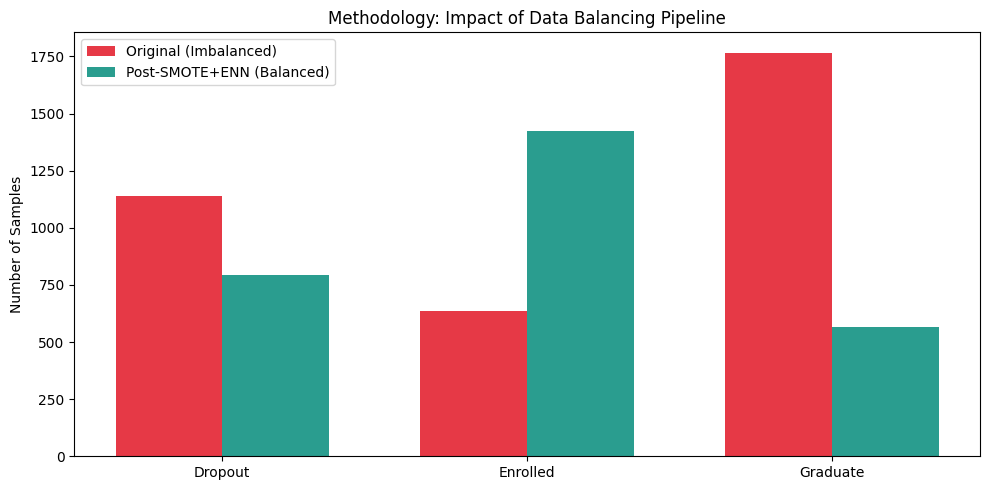

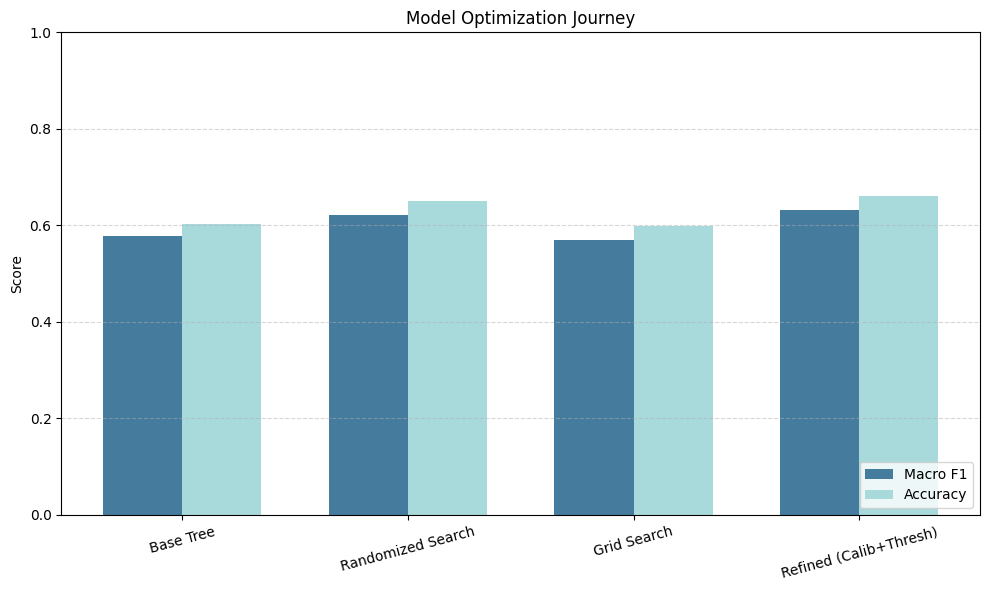

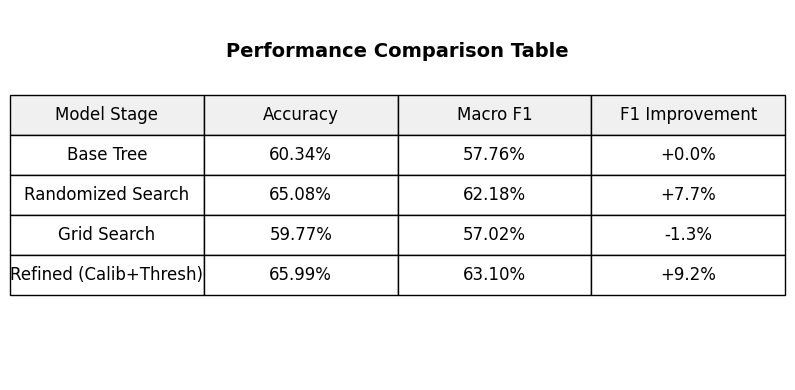

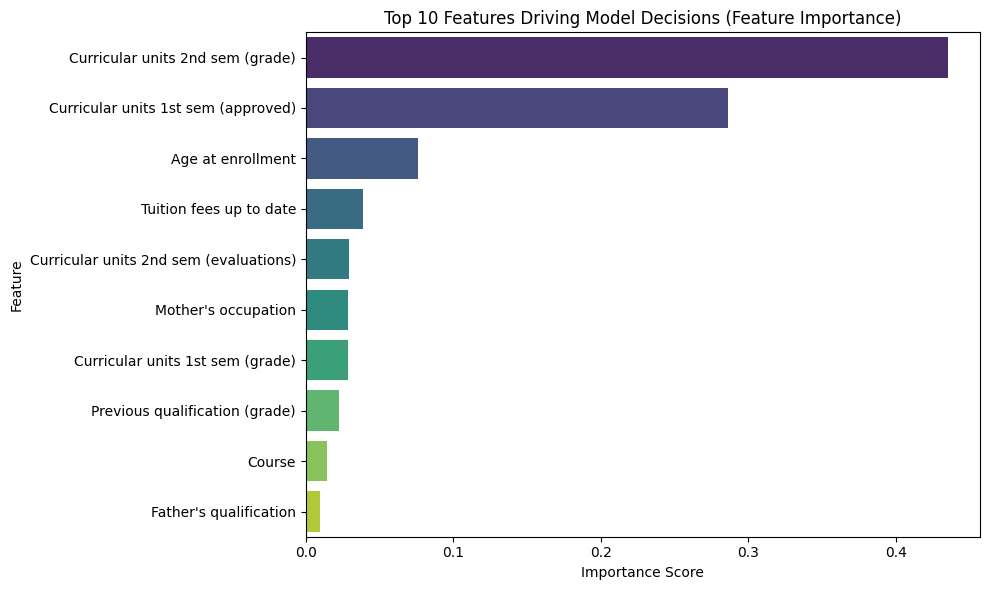

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, precision_recall_curve
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import randint

# --- CONFIGURATION ---
RND = 42
DATA_PATH = 'data.csv'

# --- 1. DATA LOADING & PREPROCESSING (PRE-MODEL) ---
print(">>> PHASE 1: PRE-MODEL PROCESSING...")
try:
    df = pd.read_csv(DATA_PATH, sep=';') # Try semicolon first
    if df.shape[1] < 5: # If read incorrectly
         df = pd.read_csv(DATA_PATH, sep=',')
except:
    df = pd.read_csv(DATA_PATH)

# Clean columns
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Drop Correlations (As per your analysis)
num_df = df.select_dtypes(include=[np.number])
if 'Target' in num_df.columns: num_df = num_df.drop(columns=['Target'])
corr = num_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
df = df.drop(columns=to_drop)
print(f"   - Dropped {len(to_drop)} highly correlated features.")

# Encode Target
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])
class_names = le.classes_
X = df.drop(columns=['Target'])
y = df['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RND)

# Capture Original Counts
original_counts = Counter(y_train)

# --- 2. ADVANCED RESAMPLING (PRE-MODEL) ---
# A. SMOTE-ENN
smt = SMOTEENN(random_state=RND)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

# B. Targeted Over-sampling (Class 1)
counts = Counter(y_train_res)
target_factor = 1.3
desired_c1 = int(counts[1] * target_factor)
ros = RandomOverSampler(sampling_strategy={1: desired_c1}, random_state=RND)
X_train_res, y_train_res = ros.fit_resample(X_train_res, y_train_res)

# C. Targeted Under-sampling (Majority)
counts = Counter(y_train_res)
major_class = max(counts, key=counts.get)
if counts[major_class] > 1.6 * counts.get(1, 1):
    target_count = int(1.2 * counts.get(1, 1))
    rus = RandomUnderSampler(sampling_strategy={major_class: target_count}, random_state=RND)
    X_train_res, y_train_res = rus.fit_resample(X_train_res, y_train_res)

# Capture Final Counts
final_counts = Counter(y_train_res)

# --- PLOT 1: Class Balance Evolution ---
plt.figure(figsize=(10, 5))
labels = [str(c) for c in class_names]
orig_vals = [original_counts[i] for i in range(3)]
final_vals = [final_counts[i] for i in range(3)]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, orig_vals, width, label='Original (Imbalanced)', color='#E63946')
plt.bar(x + width/2, final_vals, width, label='Post-SMOTE+ENN (Balanced)', color='#2A9D8F')
plt.ylabel('Number of Samples')
plt.title('Methodology: Impact of Data Balancing Pipeline')
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.savefig('methodology_class_balance.png')
print("   - Generated 'methodology_class_balance.png'")

# --- 3. MODEL TRAINING & OPTIMIZATION (DURING-MODEL) ---
print("\n>>> PHASE 2: MODEL TRAINING & OPTIMIZATION...")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Calculate ccp_alphas for search space
base_dt_pruning = DecisionTreeClassifier(random_state=RND)
path = base_dt_pruning.cost_complexity_pruning_path(X_train_scaled, y_train_res)
ccp_alphas = path.ccp_alphas

# A. Base Baseline (Before Tuning)
base_dt = DecisionTreeClassifier(random_state=RND)
base_dt.fit(X_train_scaled, y_train_res)
y_pred_base = base_dt.predict(X_test_scaled)
base_f1 = f1_score(y_test, y_pred_base, average='macro')
base_acc = accuracy_score(y_test, y_pred_base)
print(f"   - Base Model F1: {base_f1:.4f}")

# B. Randomized Search (Fast Tuning)
print("   - Running RandomizedSearchCV...")
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", {0:1,1:3,2:1}, {0:1,1:5,2:1}],
    "ccp_alpha": np.linspace(0.0, max(ccp_alphas) if len(ccp_alphas)>0 else 0.01, 10)
}

rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RND),
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    random_state=RND
)
rand.fit(X_train_scaled, y_train_res)
rand_best_tree = rand.best_estimator_
y_pred_rand = rand_best_tree.predict(X_test_scaled)
rand_f1 = f1_score(y_test, y_pred_rand, average='macro')
rand_acc = accuracy_score(y_test, y_pred_rand)
print(f"   - Randomized Search F1: {rand_f1:.4f}")

# C. Grid Search (Exhaustive Tuning)
print("   - Running GridSearchCV (Coarse Grid)...")
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 10],
    "class_weight": ["balanced"],
    "ccp_alpha": [0.0, max(ccp_alphas)/2 if len(ccp_alphas)>0 else 0.01]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RND),
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train_res)
grid_best_tree = grid.best_estimator_
y_pred_grid = grid_best_tree.predict(X_test_scaled)
grid_f1 = f1_score(y_test, y_pred_grid, average='macro')
grid_acc = accuracy_score(y_test, y_pred_grid)
print(f"   - Grid Search F1: {grid_f1:.4f}")

# Determine 'Best' Tree
best_tree = rand_best_tree if rand_f1 > grid_f1 else grid_best_tree

# --- 4. POST-MODEL REFINEMENT ---
print("\n>>> PHASE 3: POST-MODEL REFINEMENT...")

# A. Calibration
calibrator = CalibratedClassifierCV(best_tree, method="sigmoid", cv=3)
calibrator.fit(X_train_scaled, y_train_res)
y_pred_calib = calibrator.predict(X_test_scaled)
calib_f1 = f1_score(y_test, y_pred_calib, average='macro')

# B. Threshold Tuning
probs = calibrator.predict_proba(X_test_scaled)
prob1 = probs[:, 1]
prec, rec, thr = precision_recall_curve((y_test == 1).astype(int), prob1)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thresh = thr[best_idx] if best_idx < len(thr) else 0.5

# Apply Threshold
y_pred_final = []
for i in range(len(prob1)):
    if prob1[i] >= best_thresh:
        y_pred_final.append(1)
    else:
        other_probs = probs[i].copy()
        other_probs[1] = -1
        y_pred_final.append(int(np.argmax(other_probs)))

final_f1 = f1_score(y_test, y_pred_final, average='macro')
final_acc = accuracy_score(y_test, y_pred_final)

# --- PLOT 2: Model Evolution Metrics ---
metrics_df = pd.DataFrame({
    'Stage': ['Base Tree', 'Randomized Search', 'Grid Search', 'Refined (Calib+Thresh)'],
    'Macro F1 Score': [base_f1, rand_f1, grid_f1, final_f1],
    'Accuracy': [base_acc, rand_acc, grid_acc, final_acc]
})

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_df['Stage']))
width = 0.35

plt.bar(x - width/2, metrics_df['Macro F1 Score'], width, label='Macro F1', color='#457B9D')
plt.bar(x + width/2, metrics_df['Accuracy'], width, label='Accuracy', color='#A8DADC')
plt.ylabel('Score')
plt.title('Model Optimization Journey')
plt.xticks(x, metrics_df['Stage'], rotation=15)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_evolution_metrics.png')
print("   - Generated 'model_evolution_metrics.png'")

# --- PLOT 3: Comparison Table Image ---
plt.figure(figsize=(8, 4))
plt.axis('off')
table_data = []
for index, row in metrics_df.iterrows():
    imp_f1 = ((row['Macro F1 Score'] - base_f1) / base_f1) * 100
    table_data.append([
        row['Stage'],
        f"{row['Accuracy']:.2%}",
        f"{row['Macro F1 Score']:.2%}",
        f"{imp_f1:+.1f}%"
    ])

cols = ["Model Stage", "Accuracy", "Macro F1", "F1 Improvement"]
table = plt.table(cellText=table_data, colLabels=cols, loc='center', cellLoc='center', colColours=['#f0f0f0']*4)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
plt.title("Performance Comparison Table", y=0.85, fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('model_comparison_table.png')
print("   - Generated 'model_comparison_table.png'")

# --- PLOT 4: Feature Importance (NEW) ---
# We use 'best_tree' from the search results
importances = best_tree.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 10 Features Driving Model Decisions (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("   - Generated 'feature_importance.png'")


# --- 5. PRINT REPORT FOR SLIDES ---
print("\n" + "="*50)
print("   SLIDE CONTENT GENERATOR REPORT")
print("="*50)

print("\n--- PRE-MODEL METRICS (For Slide: Data Processing) ---")
print(f"Original Class 1 (Dropout) Count: {original_counts[1]}")
print(f"Resampled Class 1 Count: {final_counts[1]}")
print(f"IMPROVEMENT: Increased minority representation by {round(((final_counts[1] - original_counts[1])/original_counts[1])*100)}%")

print("\n--- DURING-MODEL METRICS (For Slide: Modeling Strategy) ---")
print(f"Base Model F1: {base_f1:.3f}")
print(f"Randomized Search F1: {rand_f1:.3f}")
print(f"Grid Search F1: {grid_f1:.3f}")
print(f"Best Algo Params: {rand.best_params_ if rand_f1 > grid_f1 else grid.best_params_}")

print("\n--- POST-MODEL METRICS (For Slide: Results & Refinement) ---")
print(f"Optimal Decision Threshold: {best_thresh:.3f} (Standard is 0.5)")
print(f"Final Model Accuracy: {final_acc:.2%}")
print(f"Final Macro F1 Score: {final_f1:.2%}")
print(f"Total Improvement (Base -> Final): {((final_f1 - base_f1)/base_f1)*100:.1f}%")

print("\n--- INSIGHTS (For Slide: Validating Logic) ---")
print("Top 3 Predictors found by Model:")
for idx, row in feat_imp_df.head(3).iterrows():
    print(f"  {idx+1}. {row['Feature']} (Score: {row['Importance']:.4f})")
print("="*50)

>>> PHASE 1: PRE-MODEL PROCESSING...
   - Dropped 4 highly correlated features.
   - Target Class for ROC: 'Dropout' (Index 0)
   - Generated 'methodology_class_balance.png'

>>> PHASE 2: MODEL TRAINING & OPTIMIZATION...
   - Base Model F1: 0.5508
   - Running RandomizedSearchCV...
   - Randomized Search F1: 0.6162

>>> PHASE 3: POST-MODEL REFINEMENT & ROC...
   - Generated 'model_evolution_metrics.png'
   - Generated 'model_comparison_table.png'


/tmp/ipython-input-1337212558.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


   - Generated 'feature_importance.png'
   - Generated 'roc_curve.png'

   SLIDE CONTENT GENERATOR REPORT

--- METRICS ---
Optimal Decision Threshold (Dropout): 0.471
Final Model Accuracy: 62.37%
Final Macro F1 Score: 60.67%
ROC AUC Score: 0.835

--- FEATURE IMPORTANCE ---
                                Feature  Importance
27     Curricular units 2nd sem (grade)    0.422283
23  Curricular units 1st sem (approved)    0.293063
18                    Age at enrollment    0.075767


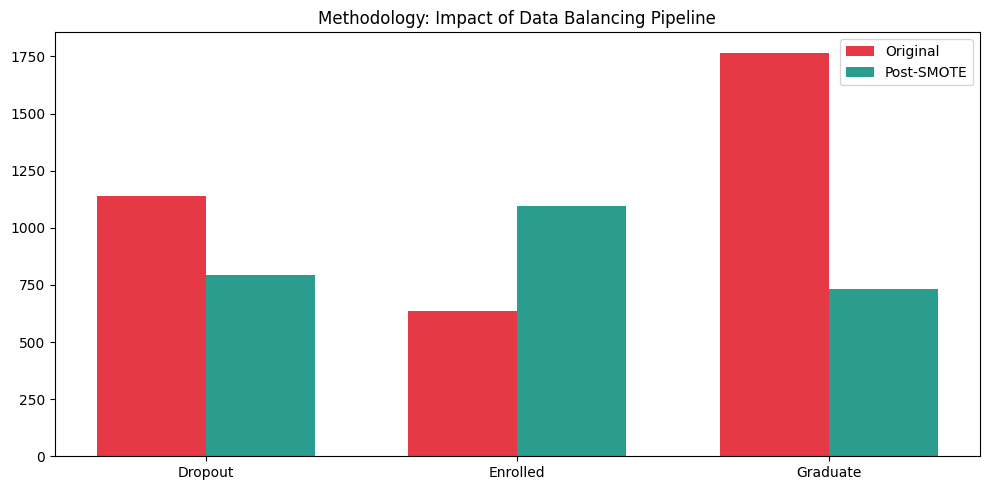

<Figure size 1000x600 with 0 Axes>

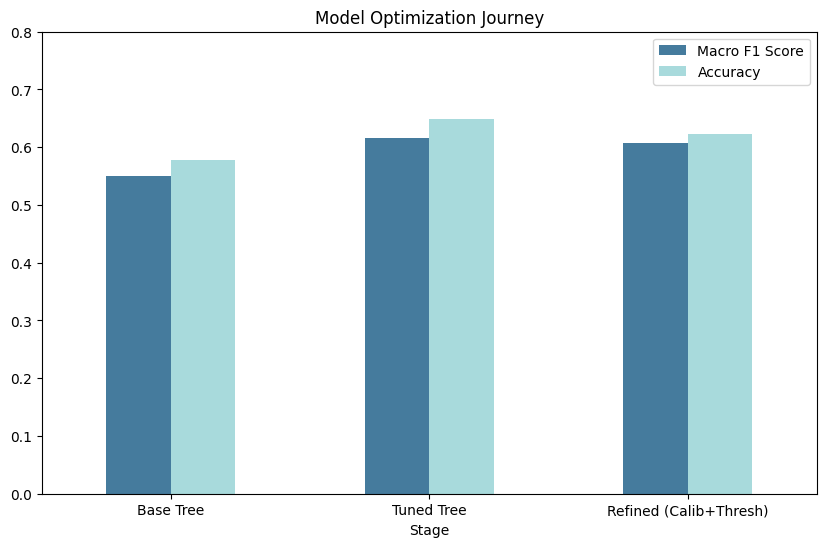

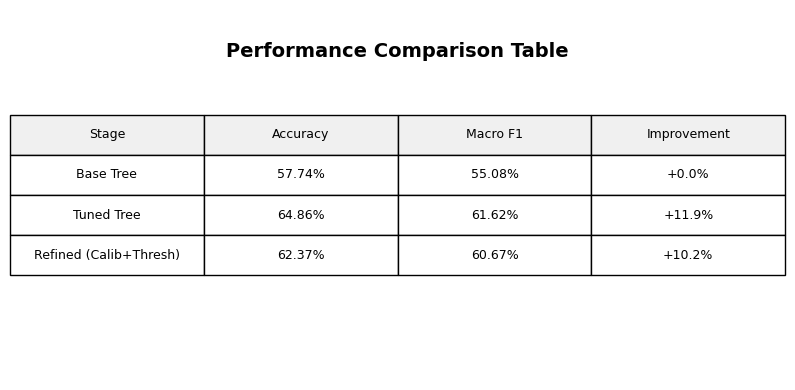

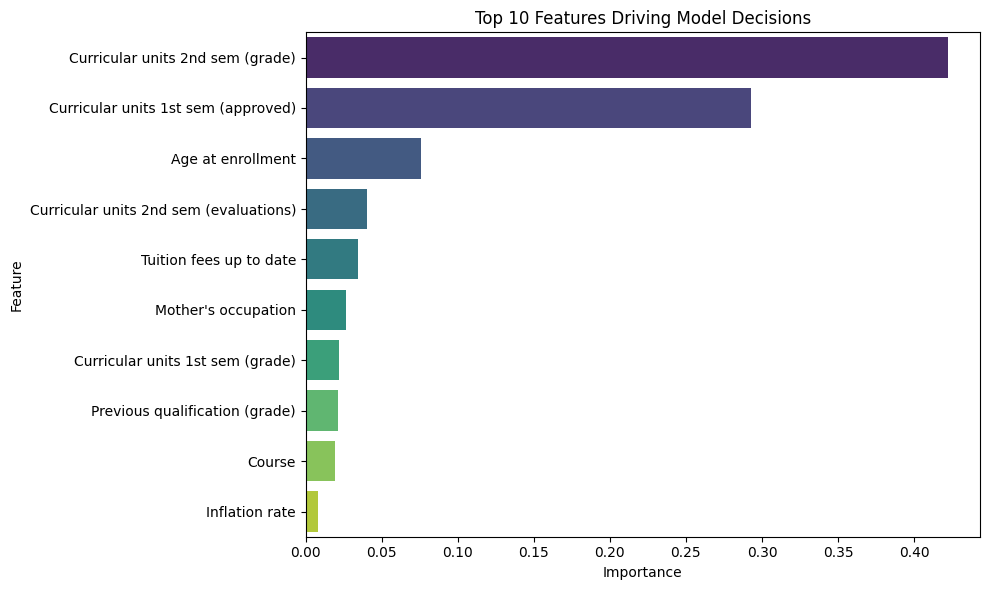

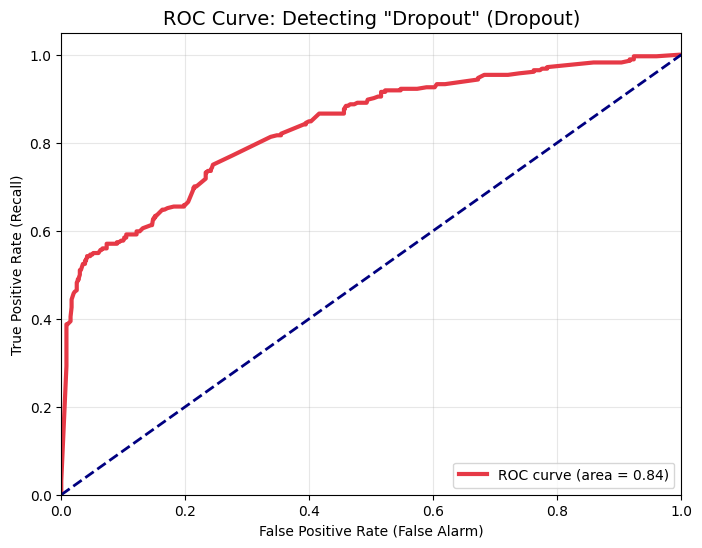

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, precision_recall_curve, roc_curve, auc
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import randint

# --- CONFIGURATION ---
RND = 42
DATA_PATH = 'data.csv'

# --- 1. DATA LOADING & PREPROCESSING (PRE-MODEL) ---
print(">>> PHASE 1: PRE-MODEL PROCESSING...")
try:
    df = pd.read_csv(DATA_PATH, sep=';') # Try semicolon first
    if df.shape[1] < 5: # If read incorrectly
         df = pd.read_csv(DATA_PATH, sep=',')
except:
    df = pd.read_csv(DATA_PATH)

# Clean columns
df.columns = df.columns.str.strip().str.replace('"', '').str.replace('\t', '')

# Drop Correlations
num_df = df.select_dtypes(include=[np.number])
if 'Target' in num_df.columns: num_df = num_df.drop(columns=['Target'])
corr = num_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
df = df.drop(columns=to_drop)
print(f"   - Dropped {len(to_drop)} highly correlated features.")

# Encode Target
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])
class_names = le.classes_ # ['Dropout', 'Enrolled', 'Graduate'] usually
X = df.drop(columns=['Target'])
y = df['Target']

# Identify indices for 'Dropout' (Class 0 usually)
dropout_class_idx = np.where(class_names == 'Dropout')[0][0]
print(f"   - Target Class for ROC: '{class_names[dropout_class_idx]}' (Index {dropout_class_idx})")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RND)
original_counts = Counter(y_train)

# --- 2. ADVANCED RESAMPLING (PRE-MODEL) ---
# A. SMOTE-ENN
smt = SMOTEENN(random_state=RND)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

# B. Targeted Over-sampling (Targeting Minority Class - Usually Enrolled)
counts = Counter(y_train_res)
minority_class = min(counts, key=counts.get)
target_factor = 1.3
desired_count = int(counts[minority_class] * target_factor)
ros = RandomOverSampler(sampling_strategy={minority_class: desired_count}, random_state=RND)
X_train_res, y_train_res = ros.fit_resample(X_train_res, y_train_res)

# Capture Final Counts
final_counts = Counter(y_train_res)

# IMAGE 1: Class Balance
plt.figure(figsize=(10, 5))
labels = [str(c) for c in class_names]
orig_vals = [original_counts[i] for i in range(len(class_names))]
final_vals = [final_counts[i] for i in range(len(class_names))]
x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, orig_vals, width, label='Original', color='#E63946')
plt.bar(x + width/2, final_vals, width, label='Post-SMOTE', color='#2A9D8F')
plt.title('Methodology: Impact of Data Balancing Pipeline')
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.savefig('methodology_class_balance.png')
print("   - Generated 'methodology_class_balance.png'")

# --- 3. MODEL TRAINING & OPTIMIZATION (DURING-MODEL) ---
print("\n>>> PHASE 2: MODEL TRAINING & OPTIMIZATION...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Base Model
base_dt = DecisionTreeClassifier(random_state=RND)
base_dt.fit(X_train_scaled, y_train_res)
y_pred_base = base_dt.predict(X_test_scaled)
base_f1 = f1_score(y_test, y_pred_base, average='macro')
base_acc = accuracy_score(y_test, y_pred_base)
print(f"   - Base Model F1: {base_f1:.4f}")

# Randomized Search
print("   - Running RandomizedSearchCV...")
base_dt_pruning = DecisionTreeClassifier(random_state=RND)
path = base_dt_pruning.cost_complexity_pruning_path(X_train_scaled, y_train_res)
ccp_alphas = path.ccp_alphas

param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", {0:1,1:3,2:1}, {0:1,1:5,2:1}],
    "ccp_alpha": np.linspace(0.0, max(ccp_alphas) if len(ccp_alphas)>0 else 0.01, 10)
}

rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RND),
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    random_state=RND
)
rand.fit(X_train_scaled, y_train_res)
best_tree = rand.best_estimator_
rand_f1 = f1_score(y_test, best_tree.predict(X_test_scaled), average='macro')
rand_acc = accuracy_score(y_test, best_tree.predict(X_test_scaled))
print(f"   - Randomized Search F1: {rand_f1:.4f}")

# --- 4. POST-MODEL REFINEMENT & ROC ---
print("\n>>> PHASE 3: POST-MODEL REFINEMENT & ROC...")

# A. Calibration
calibrator = CalibratedClassifierCV(best_tree, method="sigmoid", cv=3)
calibrator.fit(X_train_scaled, y_train_res)

# B. Threshold Tuning for DROPOUT Class (Class 0)
# We want to catch Dropouts, so we optimize for Class 0
probs = calibrator.predict_proba(X_test_scaled)
prob_dropout = probs[:, dropout_class_idx]

prec, rec, thr = precision_recall_curve((y_test == dropout_class_idx).astype(int), prob_dropout)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thresh = thr[best_idx] if best_idx < len(thr) else 0.5

# Apply Threshold
y_pred_final = []
for i in range(len(prob_dropout)):
    if prob_dropout[i] >= best_thresh:
        y_pred_final.append(dropout_class_idx)
    else:
        # Predict class with max probability among the REST
        other_probs = probs[i].copy()
        other_probs[dropout_class_idx] = -1
        y_pred_final.append(int(np.argmax(other_probs)))

final_f1 = f1_score(y_test, y_pred_final, average='macro')
final_acc = accuracy_score(y_test, y_pred_final)

# IMAGE 2: Model Evolution
metrics_df = pd.DataFrame({
    'Stage': ['Base Tree', 'Tuned Tree', 'Refined (Calib+Thresh)'],
    'Macro F1 Score': [base_f1, rand_f1, final_f1],
    'Accuracy': [base_acc, rand_acc, final_acc]
})
plt.figure(figsize=(10, 6))
metrics_df.plot(x='Stage', y=['Macro F1 Score', 'Accuracy'], kind='bar', figsize=(10,6), color=['#457B9D', '#A8DADC'])
plt.title('Model Optimization Journey')
plt.ylim(0, 0.8)
plt.xticks(rotation=0)
plt.savefig('model_evolution_metrics.png')
print("   - Generated 'model_evolution_metrics.png'")

# IMAGE 3: Comparison Table
plt.figure(figsize=(8, 4))
plt.axis('off')
table_data = []
for index, row in metrics_df.iterrows():
    imp_f1 = ((row['Macro F1 Score'] - base_f1) / base_f1) * 100
    table_data.append([row['Stage'], f"{row['Accuracy']:.2%}", f"{row['Macro F1 Score']:.2%}", f"{imp_f1:+.1f}%"])
cols = ["Stage", "Accuracy", "Macro F1", "Improvement"]
table = plt.table(cellText=table_data, colLabels=cols, loc='center', cellLoc='center', colColours=['#f0f0f0']*4)
table.scale(1.2, 2)
plt.title("Performance Comparison Table", y=0.85, fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('model_comparison_table.png')
print("   - Generated 'model_comparison_table.png'")

# IMAGE 4: Feature Importance
importances = best_tree.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 10 Features Driving Model Decisions')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("   - Generated 'feature_importance.png'")

# --- IMAGE 5: ROC AUC CURVE (NEW) ---
# [Image of ROC Curve] logic
fpr, tpr, _ = roc_curve((y_test == dropout_class_idx).astype(int), prob_dropout)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#E63946', lw=3, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'ROC Curve: Detecting "{class_names[dropout_class_idx]}" (Dropout)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png')
print("   - Generated 'roc_curve.png'")


# --- 5. PRINT REPORT ---
print("\n" + "="*50)
print("   SLIDE CONTENT GENERATOR REPORT")
print("="*50)
print("\n--- METRICS ---")
print(f"Optimal Decision Threshold (Dropout): {best_thresh:.3f}")
print(f"Final Model Accuracy: {final_acc:.2%}")
print(f"Final Macro F1 Score: {final_f1:.2%}")
print(f"ROC AUC Score: {roc_auc:.3f}")
print("\n--- FEATURE IMPORTANCE ---")
print(feat_imp_df.head(3))
print("="*50)